In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/drive/My Drive/Project_DataMining/data/raw/Predict Hair Fall.csv")

In [ ]:
df.shape

(999, 13)

In [ ]:
df.head()

,Id,Genetics,Hormonal Changes,Medical Conditions,Medications & Treatments,Nutritional Deficiencies,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss
0,133992,Yes,No,No Data,No Data,Magnesium deficiency,Moderate,19,Yes,Yes,No,No,0
1,148393,No,No,Eczema,Antibiotics,Magnesium deficiency,High,43,Yes,Yes,No,No,0
2,155074,No,No,Dermatosis,Antifungal Cream,Protein deficiency,Moderate,26,Yes,Yes,No,Yes,0
3,118261,Yes,Yes,Ringworm,Antibiotics,Biotin Deficiency,Moderate,46,Yes,Yes,No,No,0
4,111915,No,No,Psoriasis,Accutane,Iron deficiency,Moderate,30,No,Yes,Yes,No,1


In [ ]:
df.columns

Index(['Id', 'Genetics', 'Hormonal Changes', 'Medical Conditions',
       'Medications & Treatments', 'Nutritional Deficiencies ', 'Stress',
       'Age', 'Poor Hair Care Habits ', 'Environmental Factors', 'Smoking',
       'Weight Loss ', 'Hair Loss'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Id                         999 non-null    int64 
 1   Genetics                   999 non-null    object
 2   Hormonal Changes           999 non-null    object
 3   Medical Conditions         999 non-null    object
 4   Medications & Treatments   999 non-null    object
 5   Nutritional Deficiencies   999 non-null    object
 6   Stress                     999 non-null    object
 7   Age                        999 non-null    int64 
 8   Poor Hair Care Habits      999 non-null    object
 9   Environmental Factors      999 non-null    object
 10  Smoking                    999 non-null    object
 11  Weight Loss                999 non-null    object
 12  Hair Loss                  999 non-null    int64 
dtypes: int64(3), object(10)
memory usage: 101.6+ KB


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.isnull().sum()

,0
Id,0
Genetics,0
Hormonal Changes,0
Medical Conditions,0
Medications & Treatments,0
Nutritional Deficiencies,0
Stress,0
Age,0
Poor Hair Care Habits,0
Environmental Factors,0


In [ ]:
df = df.drop('Id', axis = 1)

df.head()

,Genetics,Hormonal Changes,Medical Conditions,Medications & Treatments,Nutritional Deficiencies,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss
0,Yes,No,No Data,No Data,Magnesium deficiency,Moderate,19,Yes,Yes,No,No,0
1,No,No,Eczema,Antibiotics,Magnesium deficiency,High,43,Yes,Yes,No,No,0
2,No,No,Dermatosis,Antifungal Cream,Protein deficiency,Moderate,26,Yes,Yes,No,Yes,0
3,Yes,Yes,Ringworm,Antibiotics,Biotin Deficiency,Moderate,46,Yes,Yes,No,No,0
4,No,No,Psoriasis,Accutane,Iron deficiency,Moderate,30,No,Yes,Yes,No,1


In [ ]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

df.head()

,Genetics,Hormonal_Changes,Medical_Conditions,Medications_&_Treatments,Nutritional_Deficiencies,Stress,Age,Poor_Hair_Care_Habits,Environmental_Factors,Smoking,Weight_Loss,Hair_Loss
0,Yes,No,No Data,No Data,Magnesium deficiency,Moderate,19,Yes,Yes,No,No,0
1,No,No,Eczema,Antibiotics,Magnesium deficiency,High,43,Yes,Yes,No,No,0
2,No,No,Dermatosis,Antifungal Cream,Protein deficiency,Moderate,26,Yes,Yes,No,Yes,0
3,Yes,Yes,Ringworm,Antibiotics,Biotin Deficiency,Moderate,46,Yes,Yes,No,No,0
4,No,No,Psoriasis,Accutane,Iron deficiency,Moderate,30,No,Yes,Yes,No,1


In [ ]:
df_eda = df.copy()

df_eda.head()

,Genetics,Hormonal_Changes,Medical_Conditions,Medications_&_Treatments,Nutritional_Deficiencies,Stress,Age,Poor_Hair_Care_Habits,Environmental_Factors,Smoking,Weight_Loss,Hair_Loss
0,Yes,No,No Data,No Data,Magnesium deficiency,Moderate,19,Yes,Yes,No,No,0
1,No,No,Eczema,Antibiotics,Magnesium deficiency,High,43,Yes,Yes,No,No,0
2,No,No,Dermatosis,Antifungal Cream,Protein deficiency,Moderate,26,Yes,Yes,No,Yes,0
3,Yes,Yes,Ringworm,Antibiotics,Biotin Deficiency,Moderate,46,Yes,Yes,No,No,0
4,No,No,Psoriasis,Accutane,Iron deficiency,Moderate,30,No,Yes,Yes,No,1


In [ ]:
label_hair = {0:'No', 1:'Yes'}

df_eda['Hair_Loss'] = df_eda['Hair_Loss'].map(label_hair)

df_eda.head()

,Genetics,Hormonal_Changes,Medical_Conditions,Medications_&_Treatments,Nutritional_Deficiencies,Stress,Age,Poor_Hair_Care_Habits,Environmental_Factors,Smoking,Weight_Loss,Hair_Loss
0,Yes,No,No Data,No Data,Magnesium deficiency,Moderate,19,Yes,Yes,No,No,No
1,No,No,Eczema,Antibiotics,Magnesium deficiency,High,43,Yes,Yes,No,No,No
2,No,No,Dermatosis,Antifungal Cream,Protein deficiency,Moderate,26,Yes,Yes,No,Yes,No
3,Yes,Yes,Ringworm,Antibiotics,Biotin Deficiency,Moderate,46,Yes,Yes,No,No,No
4,No,No,Psoriasis,Accutane,Iron deficiency,Moderate,30,No,Yes,Yes,No,Yes


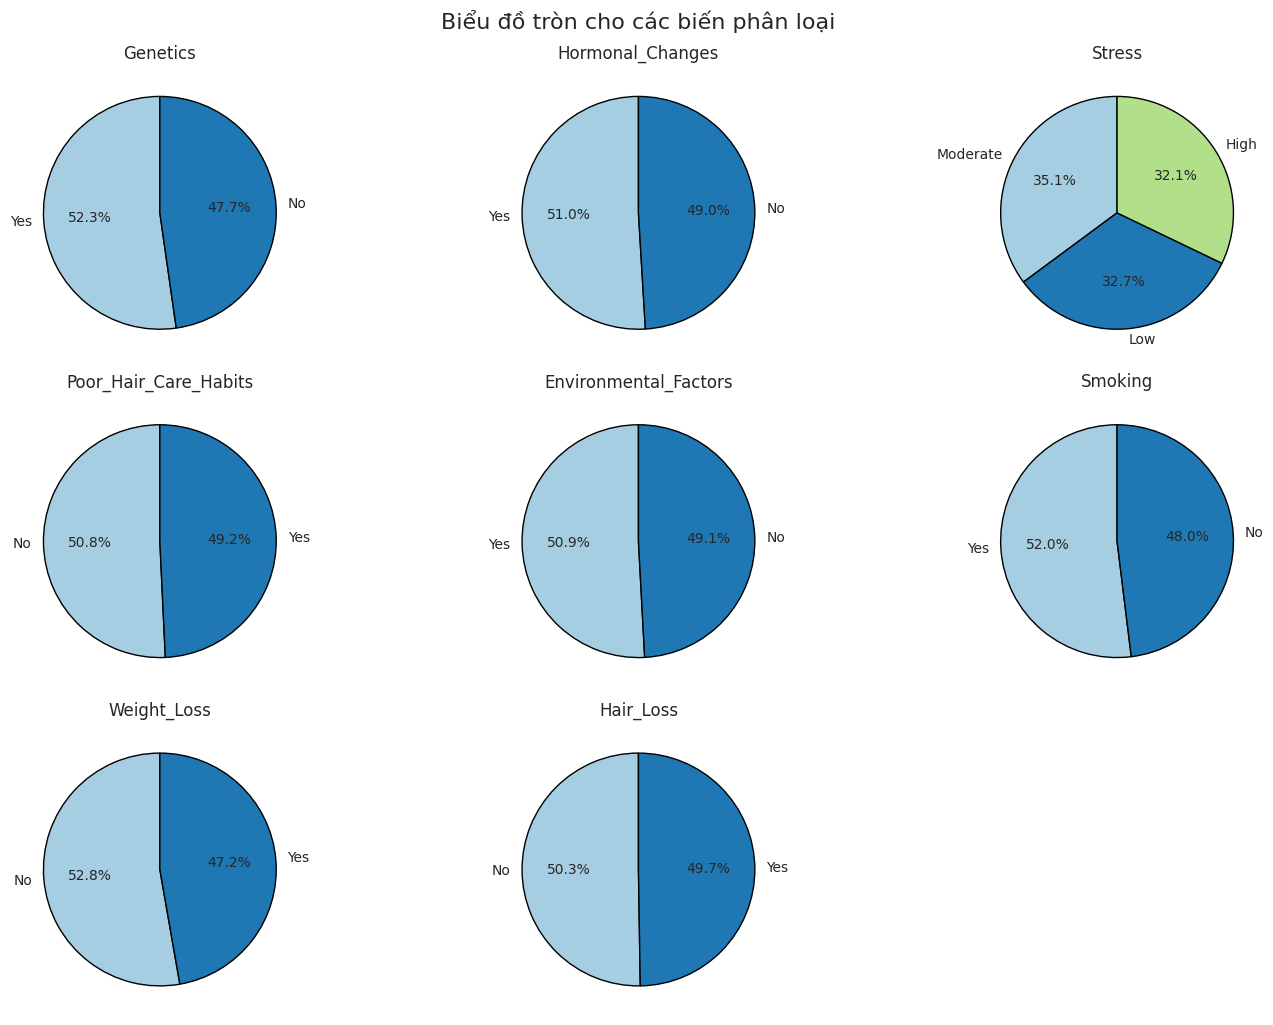

In [ ]:
num_cols = ['Genetics', 'Hormonal_Changes', 'Stress',
            'Poor_Hair_Care_Habits', 'Environmental_Factors',
            'Smoking', 'Weight_Loss', 'Hair_Loss']

# Thiết lập kích thước Figure
plt.figure(figsize=(15, 10))

# Vòng lặp qua từng cột để vẽ biểu đồ tròn
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    value_counts = df_eda[col].value_counts()

    # Vẽ biểu đồ tròn
    plt.pie(
        value_counts,
        labels=value_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Paired.colors,
        wedgeprops={'edgecolor': 'black'}
    )
    plt.title(f"{col}")

# Điều chỉnh bố cục để tránh chồng chéo
plt.tight_layout()
plt.suptitle("Biểu đồ tròn cho các biến phân loại", fontsize=16, y=1.02)
plt.show()

<ipython-input-47-9a9b4062088e>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, y=col, palette='dark', ax=ax)
<ipython-input-47-9a9b4062088e>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, y=col, palette='dark', ax=ax)
<ipython-input-47-9a9b4062088e>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, y=col, palette='dark', ax=ax)
<ipython-input-47-9a9b4062088e>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable t

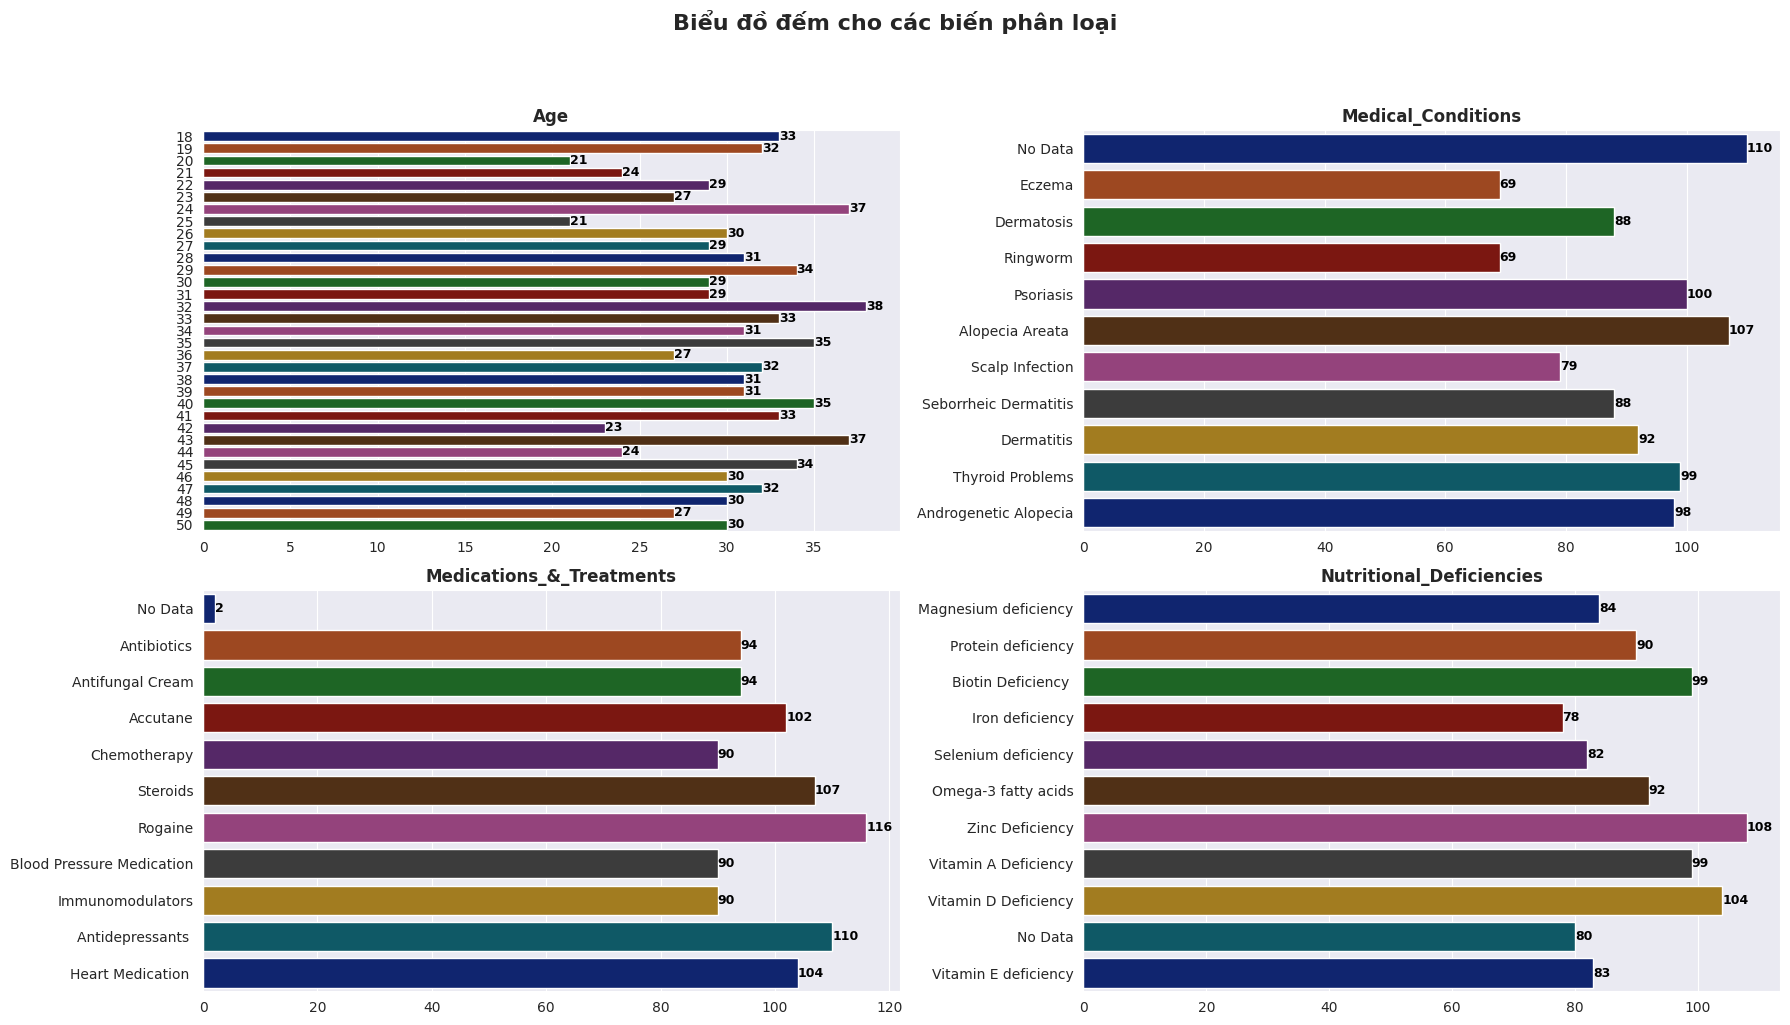

In [ ]:
cat_cols = ['Age', 'Medical_Conditions', 'Medications_&_Treatments', 'Nutritional_Deficiencies']

sns.set_style("darkgrid")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
fig.suptitle("Biểu đồ đếm cho các biến phân loại", fontsize=16, fontweight='bold', y=1.02)

# Vòng lặp qua từng cột để vẽ biểu đồ đếm
for idx, col in enumerate(cat_cols):
    row, col_idx = divmod(idx, 2)  # Tính toán chỉ số hàng và cột
    ax = axes[row, col_idx]

    # Vẽ biểu đồ đếm
    sns.countplot(data=df_eda, y=col, palette='dark', ax=ax)

    # Thêm nhãn cho từng thanh
    for bars in ax.containers:
        if len(bars.datavalues) > 0:  # Kiểm tra xem có dữ liệu hay không
            ax.bar_label(bars, fontsize=9, fontweight='bold', color='black')

    # Thiết lập tiêu đề
    ax.set_title(f"{col}", fontsize=12, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("")

# Điều chỉnh bố cục để tránh chồng chéo
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

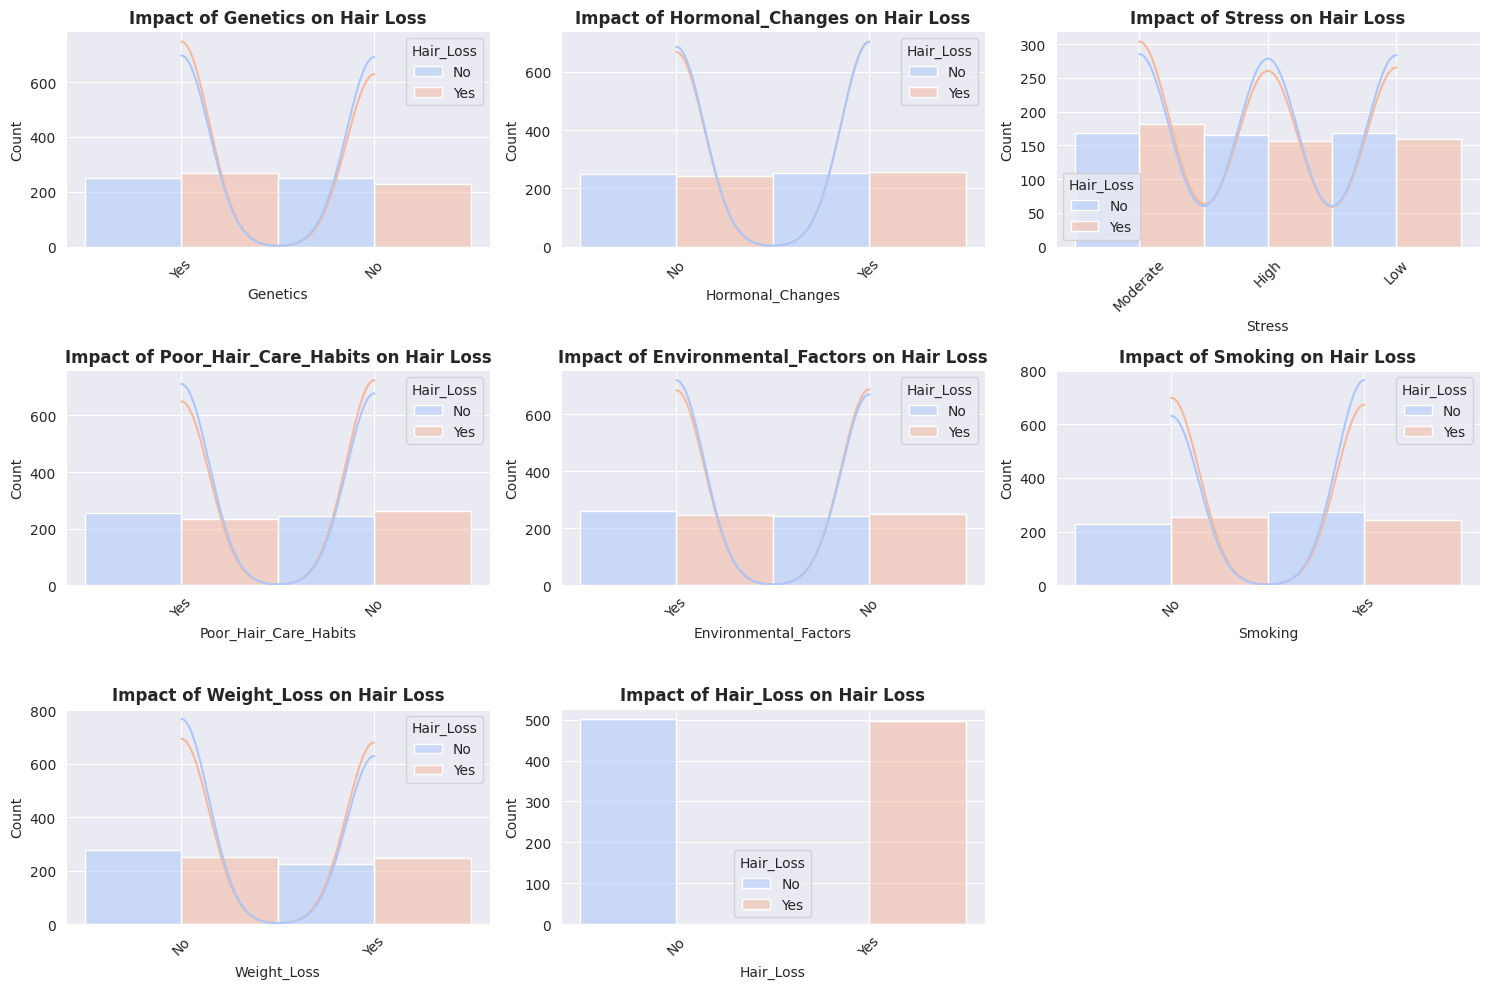

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(
        data=df_eda,
        x=col,
        hue="Hair_Loss",
        bins=30,
        kde=True,
        palette="coolwarm",
        multiple="dodge"
    )
    plt.title(f"Impact of {col} on Hair Loss", fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

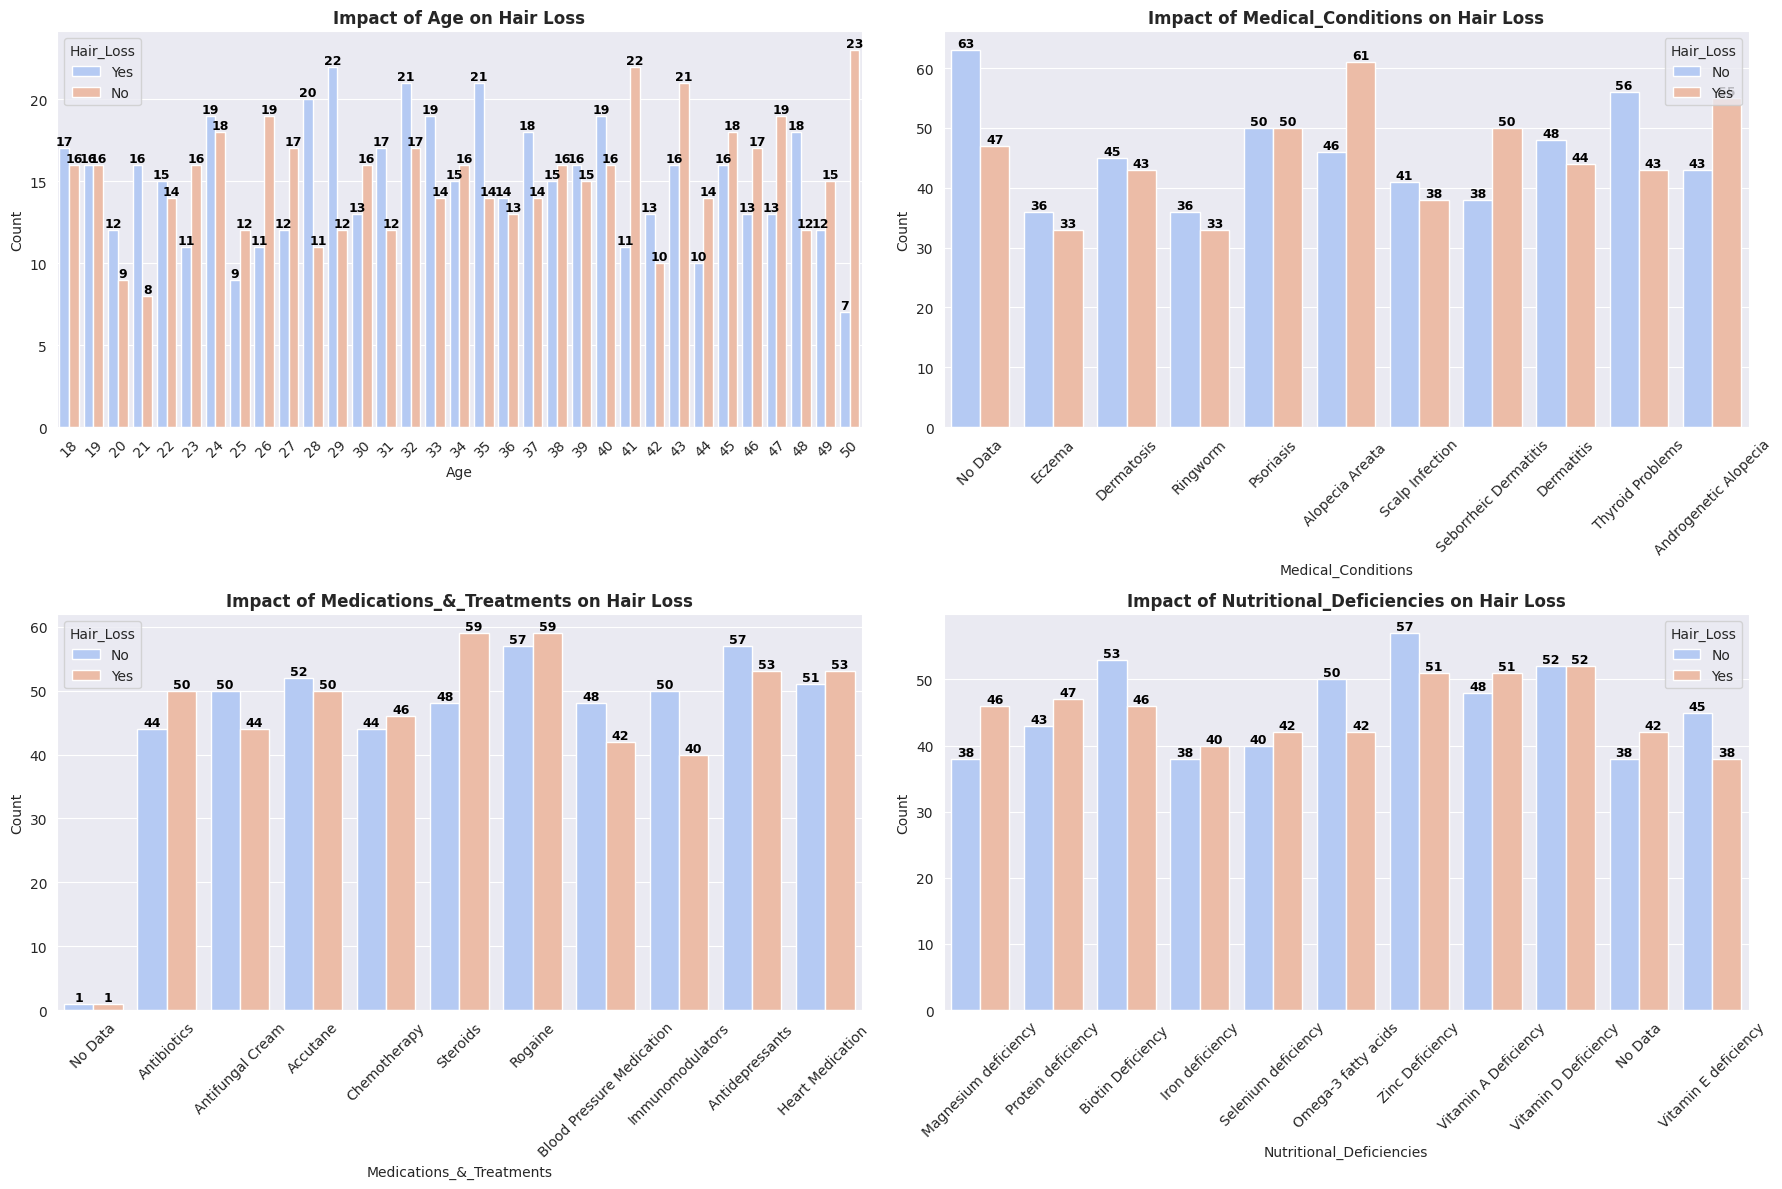

In [ ]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    ax = sns.countplot(
        data=df_eda,
        x=col,
        hue="Hair_Loss",
        palette="coolwarm"
    )

    for bars in ax.containers:
        ax.bar_label(bars, fontsize=9, fontweight='bold', color='black')

    plt.title(f"Impact of {col} on Hair Loss", fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

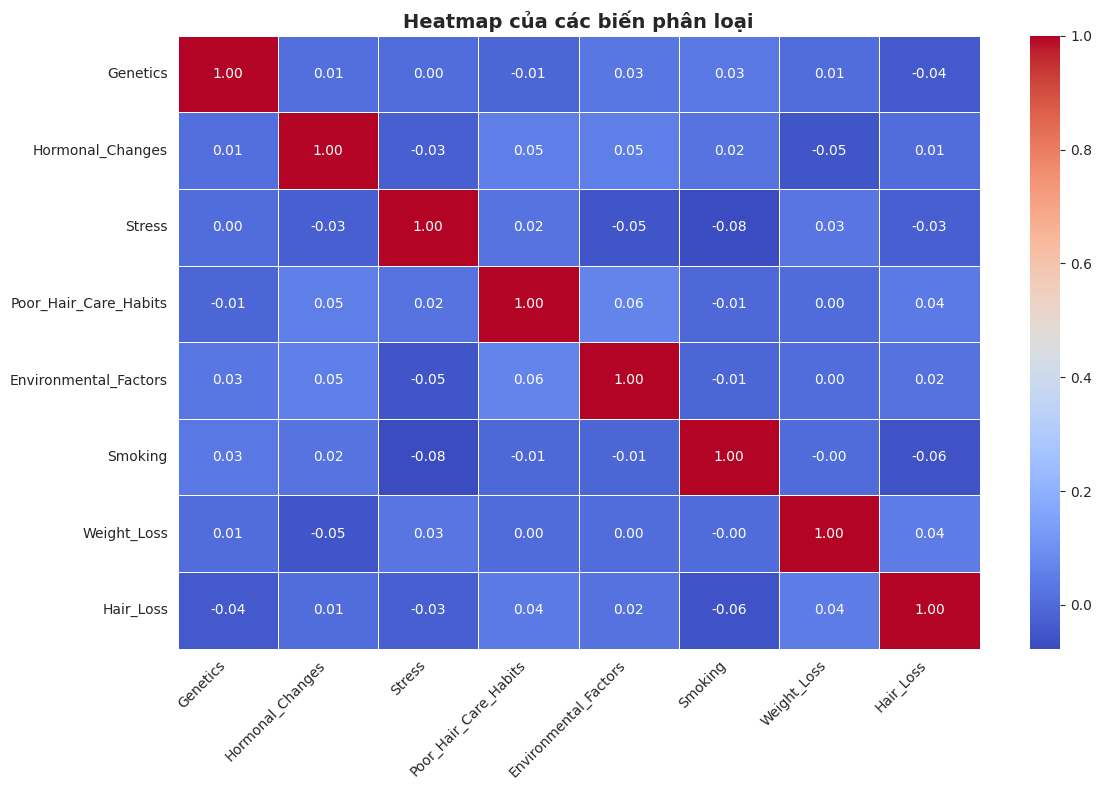

In [ ]:
# Tạo bản sao dữ liệu
df_heatmap = df_eda[num_cols].copy()

# Chuyển đổi dữ liệu phân loại sang dữ liệu số
df_heatmap = df_heatmap.apply(lambda x: pd.factorize(x)[0])

# Tính toán ma trận tương quan
corr_matrix = df_heatmap.corr()

# Vẽ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True, linewidths=0.5)
plt.title("Heatmap của các biến phân loại", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Sử dụng set để tránh lặp cặp
checked_pairs = set()

for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 != col2 and (col2, col1) not in checked_pairs:
            checked_pairs.add((col1, col2))

            print(f"\nBảng tần suất giữa '{col1}' và '{col2}':")
            crosstab = pd.crosstab(df[col1], df[col2])
            display(crosstab)


Bảng tần suất giữa 'Age' và 'Medical_Conditions':


Medical_Conditions,Alopecia Areata,Androgenetic Alopecia,Dermatitis,Dermatosis,Eczema,No Data,Psoriasis,Ringworm,Scalp Infection,Seborrheic Dermatitis,Thyroid Problems
Age,,,,,,,,,,,
18,3,0,3,0,1,15,2,3,2,2,2
19,2,1,3,5,2,9,1,1,3,3,2
20,7,2,0,2,1,4,1,1,1,1,1
21,3,3,4,3,2,0,2,0,1,2,4
22,1,3,5,5,1,0,4,3,1,6,0
23,5,3,1,0,1,0,3,6,3,1,4
24,5,6,4,5,3,0,3,2,5,3,1
25,1,2,1,3,2,0,2,3,0,5,2
26,2,5,3,5,6,0,2,1,3,1,2



Bảng tần suất giữa 'Age' và 'Medications_&_Treatments':


Medications_&_Treatments,Accutane,Antibiotics,Antidepressants,Antifungal Cream,Blood Pressure Medication,Chemotherapy,Heart Medication,Immunomodulators,No Data,Rogaine,Steroids
Age,,,,,,,,,,,
18,1,1,7,5,2,1,10,1,0,3,2
19,3,4,4,1,3,6,1,4,1,2,3
20,1,2,2,3,2,2,2,1,0,2,4
21,5,3,3,2,2,2,3,1,0,2,1
22,2,2,3,2,2,7,2,3,0,3,3
23,2,2,1,3,2,4,3,2,0,2,6
24,4,2,5,2,7,5,2,1,0,5,4
25,1,3,2,2,3,1,0,5,0,2,2
26,4,3,5,3,2,1,4,3,0,2,3



Bảng tần suất giữa 'Age' và 'Nutritional_Deficiencies':


...

Medications_&_Treatments,Accutane,Antibiotics,Antidepressants,Antifungal Cream,Blood Pressure Medication,Chemotherapy,Heart Medication,Immunomodulators,No Data,Rogaine,Steroids
Medical_Conditions,,,,,,,,,,,
Alopecia Areata,16,8,13,15,10,10,8,9,0,9,9
Androgenetic Alopecia,6,10,10,11,5,11,10,13,0,16,6
Dermatitis,7,10,10,11,6,7,12,9,0,10,10
Dermatosis,7,9,10,10,7,7,12,5,0,16,5
Eczema,3,9,8,4,7,7,9,5,0,7,10
No Data,13,9,16,11,9,9,13,10,2,8,10
Psoriasis,9,11,9,10,13,9,10,9,0,8,12
Ringworm,5,8,4,4,6,8,8,7,0,8,11
Scalp Infection,7,3,10,8,7,8,4,9,0,13,10



Bảng tần suất giữa 'Medical_Conditions' và 'Nutritional_Deficiencies':


Nutritional_Deficiencies,Biotin Deficiency,Iron deficiency,Magnesium deficiency,No Data,Omega-3 fatty acids,Protein deficiency,Selenium deficiency,Vitamin A Deficiency,Vitamin D Deficiency,Vitamin E deficiency,Zinc Deficiency
Medical_Conditions,,,,,,,,,,,
Alopecia Areata,14,8,9,9,7,10,13,10,10,8,9
Androgenetic Alopecia,13,11,9,9,4,9,4,11,15,8,5
Dermatitis,9,9,9,10,11,5,6,5,10,4,14
Dermatosis,3,4,6,8,12,9,5,9,12,10,10
Eczema,7,2,10,4,5,7,3,7,8,6,10
No Data,10,10,13,0,10,11,14,8,10,12,12
Psoriasis,6,9,12,9,11,12,7,13,7,5,9
Ringworm,6,3,3,9,5,6,10,6,5,5,11
Scalp Infection,11,3,2,5,6,8,9,8,10,7,10



Bảng tần suất giữa 'Medications_&_Treatments' và 'Nutritional_Deficiencies':


Nutritional_Deficiencies,Biotin Deficiency,Iron deficiency,Magnesium deficiency,No Data,Omega-3 fatty acids,Protein deficiency,Selenium deficiency,Vitamin A Deficiency,Vitamin D Deficiency,Vitamin E deficiency,Zinc Deficiency
Medications_&_Treatments,,,,,,,,,,,
Accutane,11,9,5,9,10,12,9,10,4,11,12
Antibiotics,9,7,9,7,6,11,5,14,13,5,8
Antidepressants,9,9,5,7,6,16,15,9,18,6,10
Antifungal Cream,11,6,4,7,6,8,12,7,12,6,15
Blood Pressure Medication,10,5,12,6,11,2,5,12,8,7,12
Chemotherapy,10,8,10,13,5,6,5,5,10,8,10
Heart Medication,10,7,6,8,16,6,10,10,13,11,7
Immunomodulators,8,7,8,6,7,8,7,11,6,9,13
No Data,0,0,1,0,0,0,1,0,0,0,0


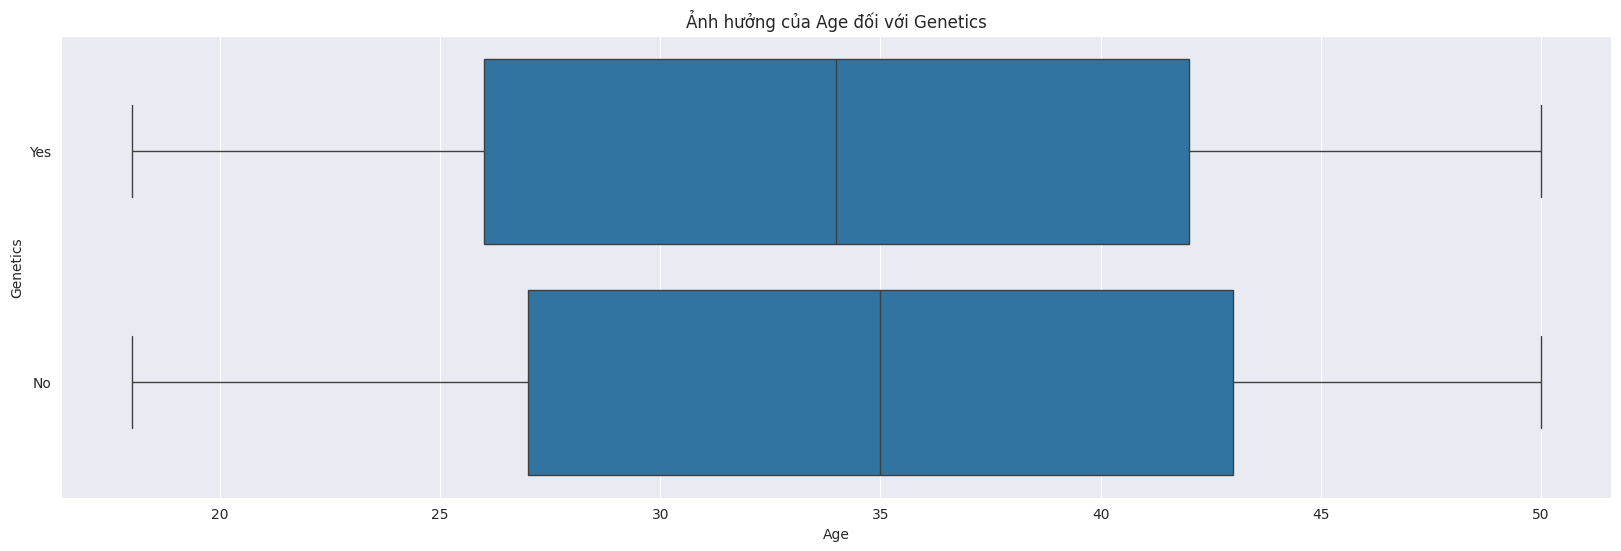

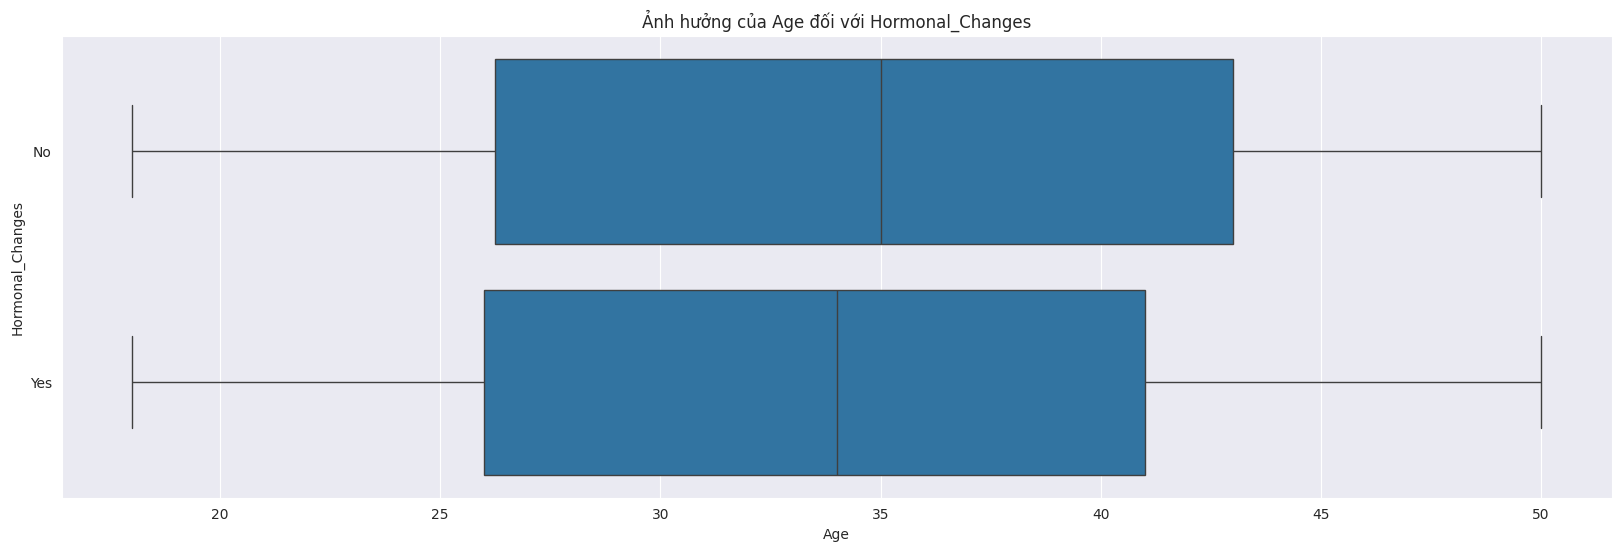

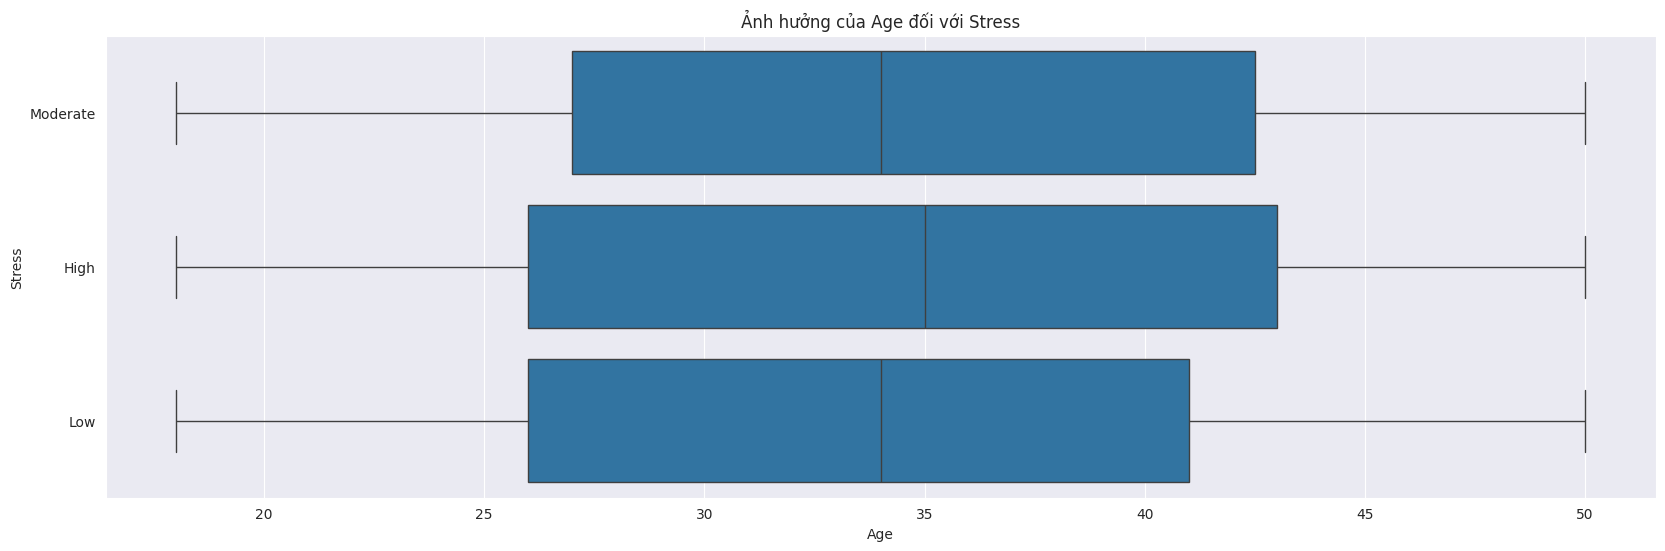

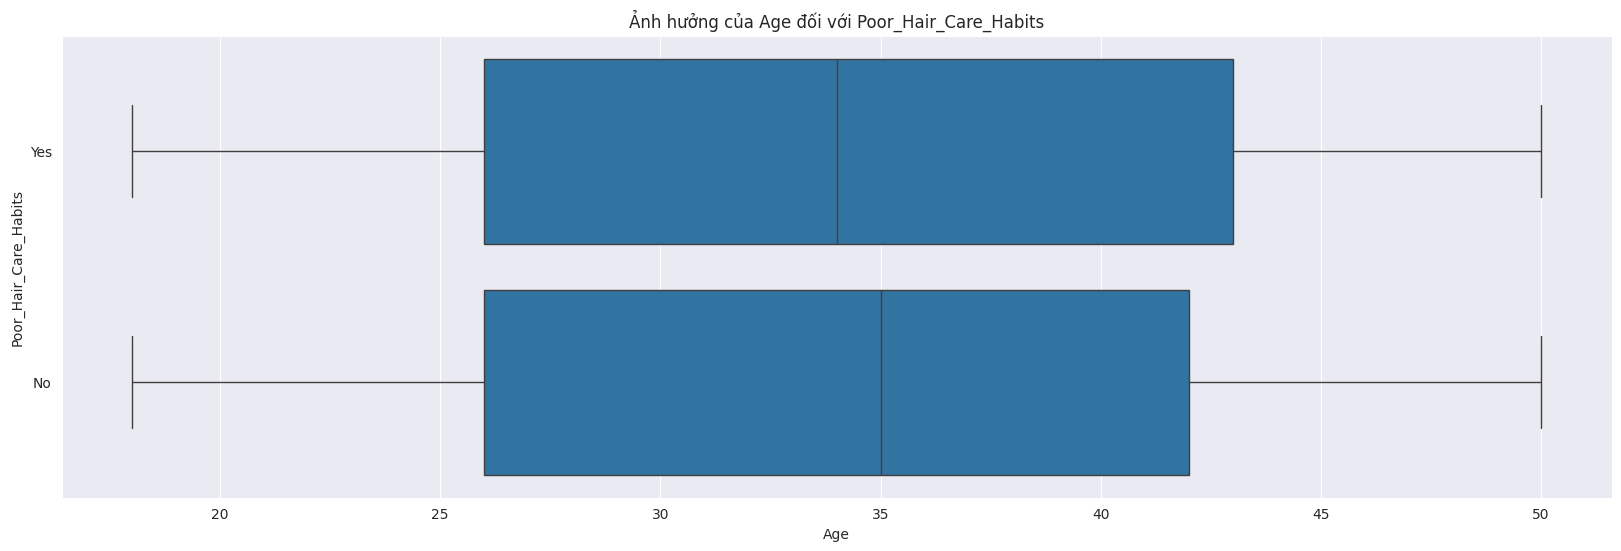

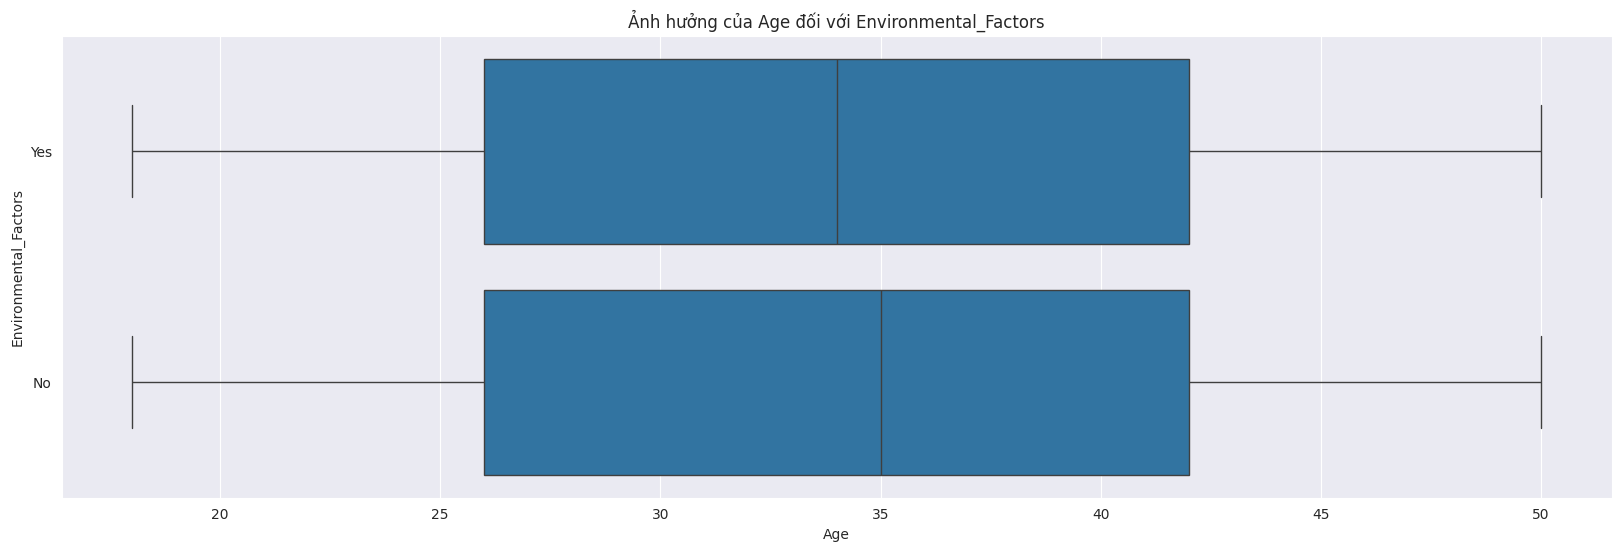

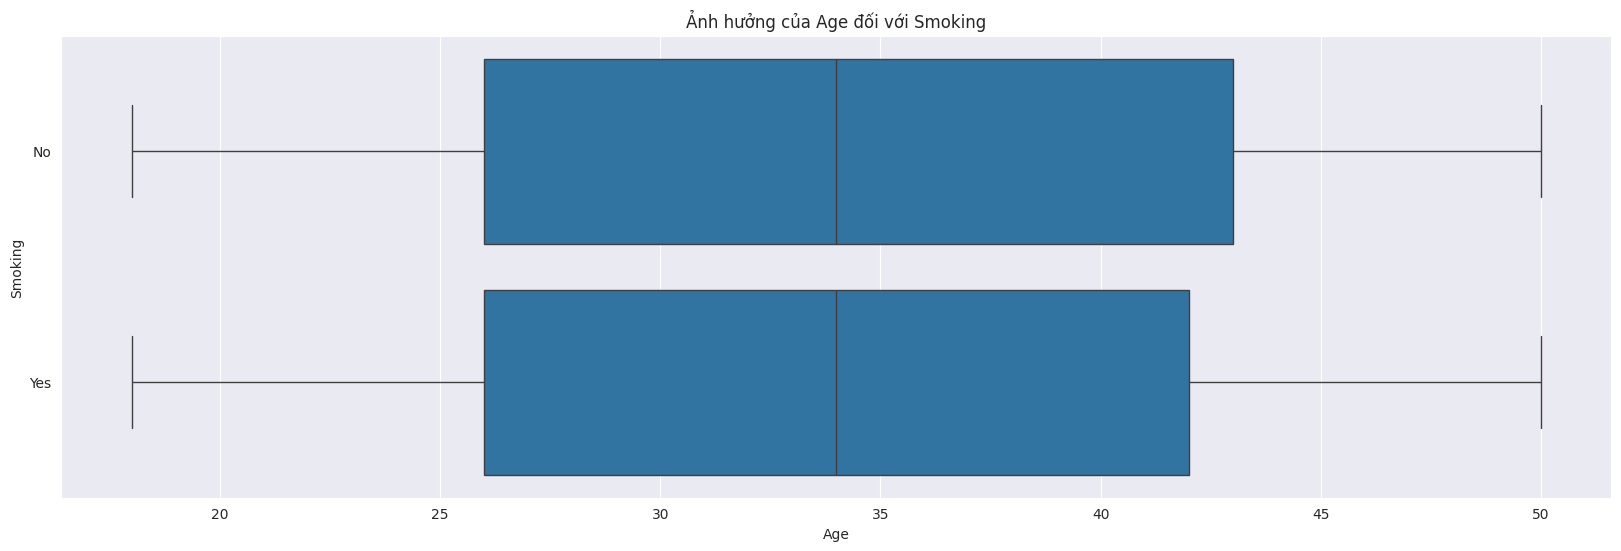

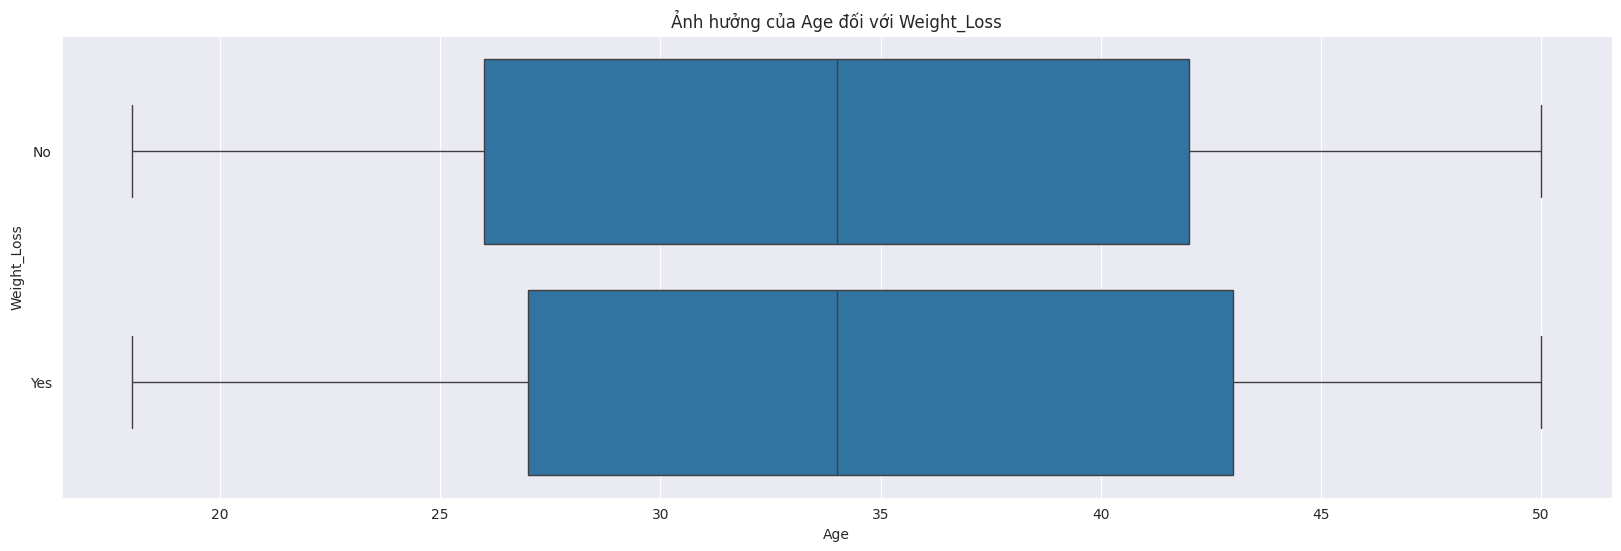

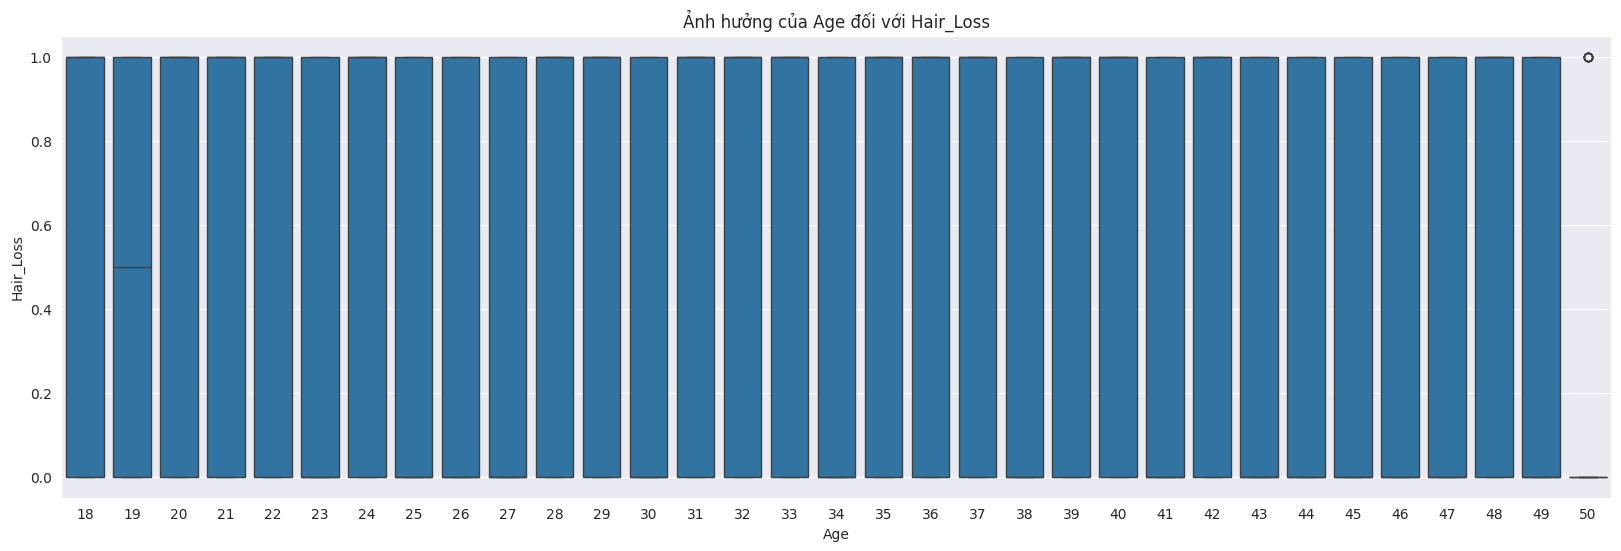

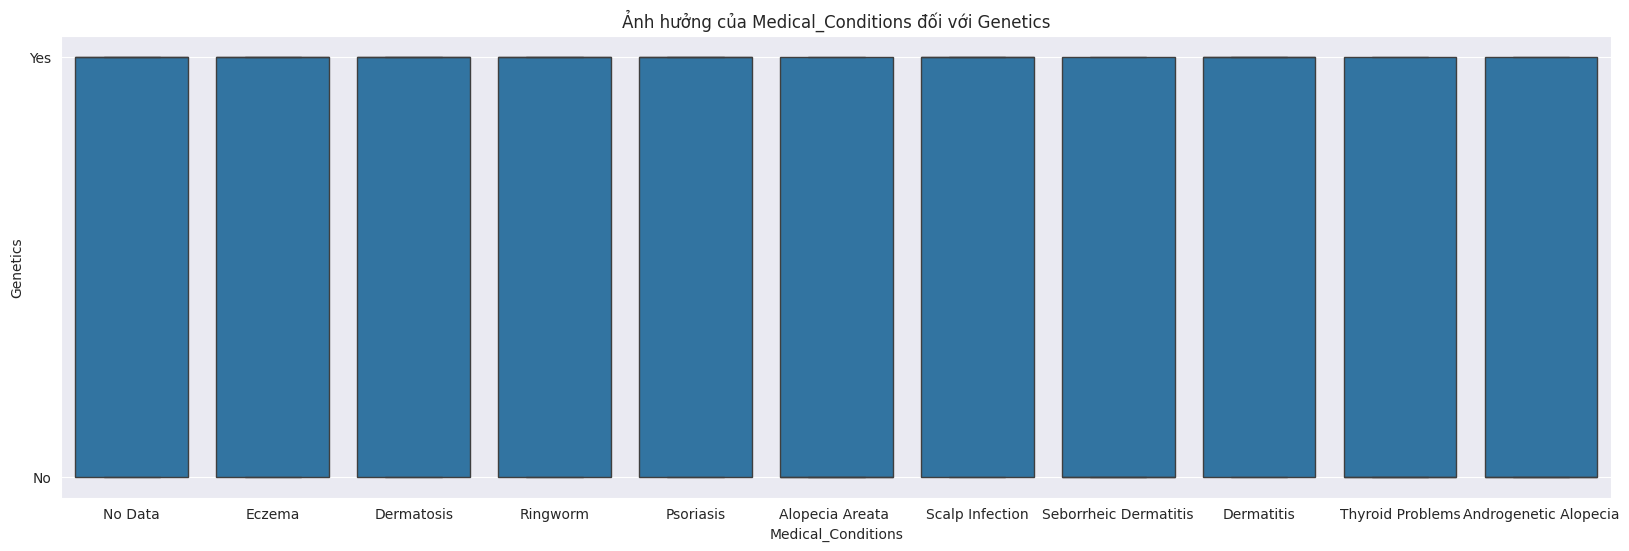

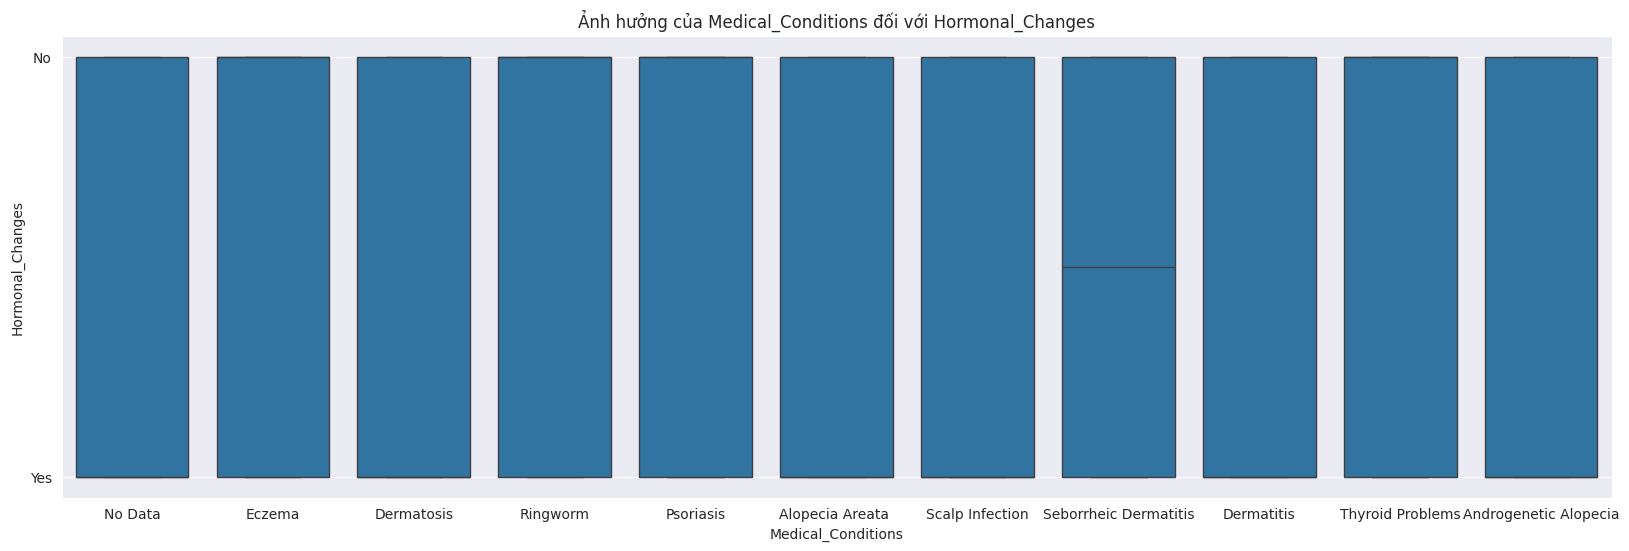

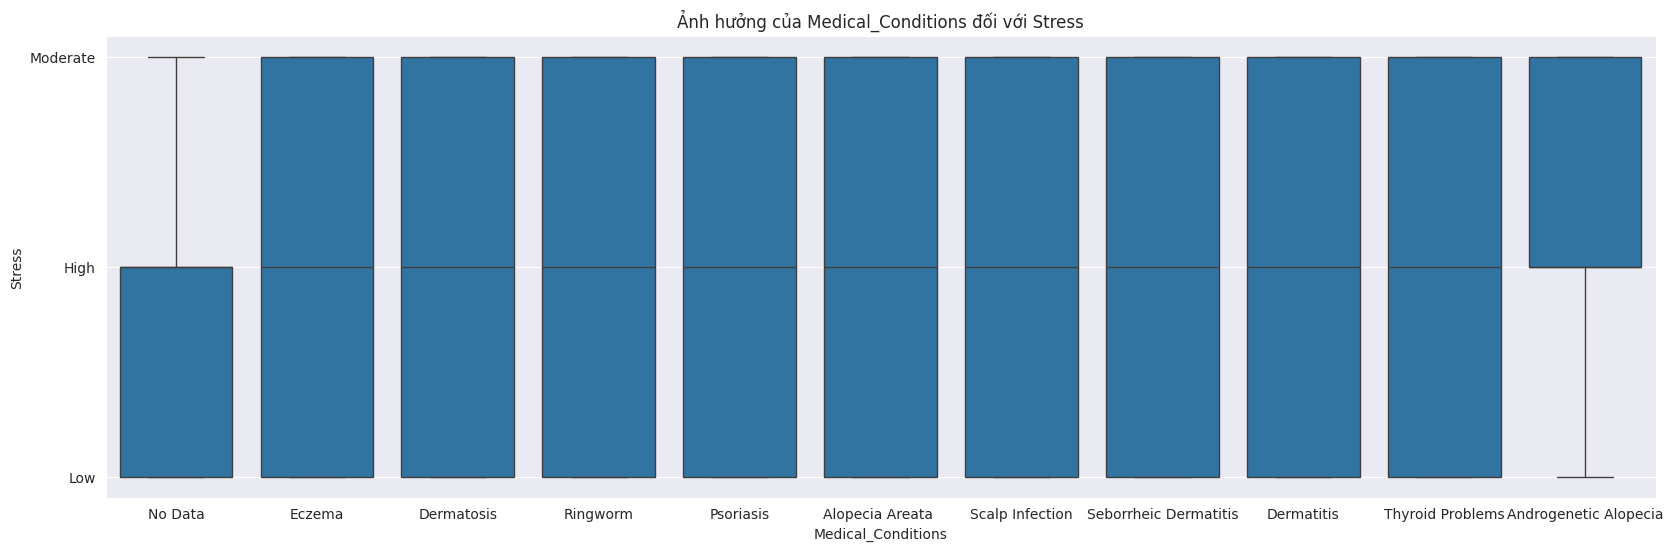

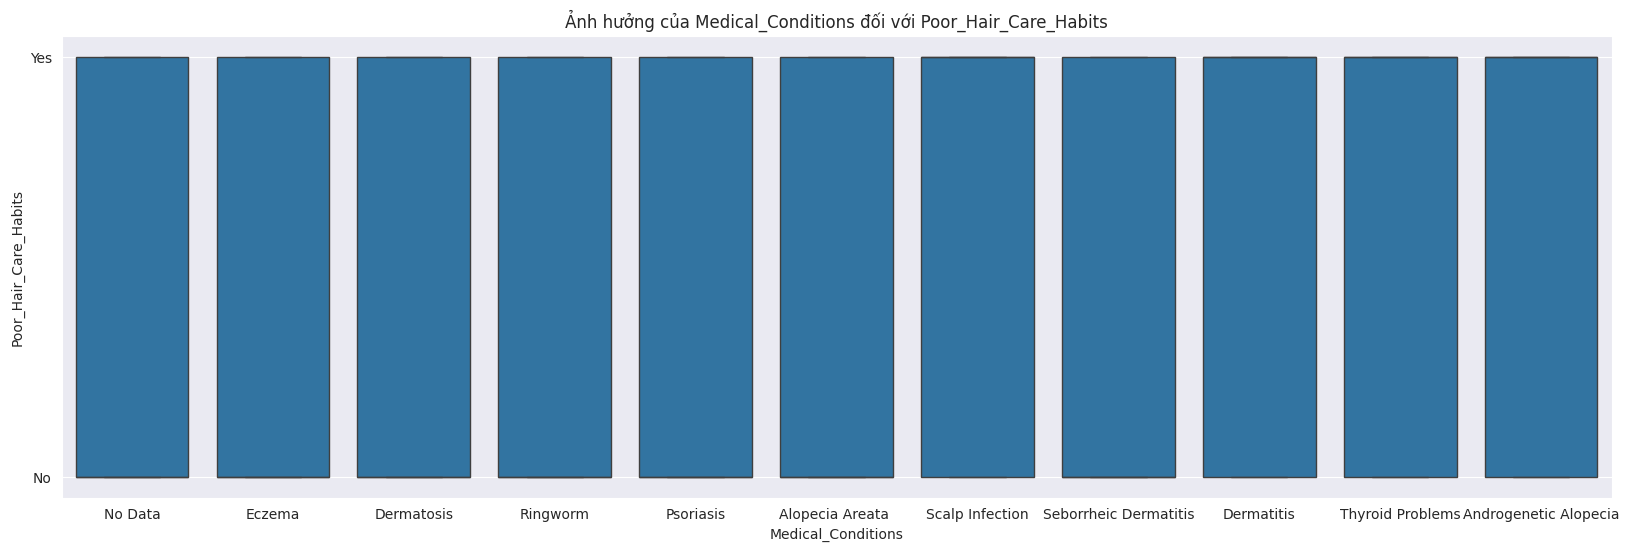

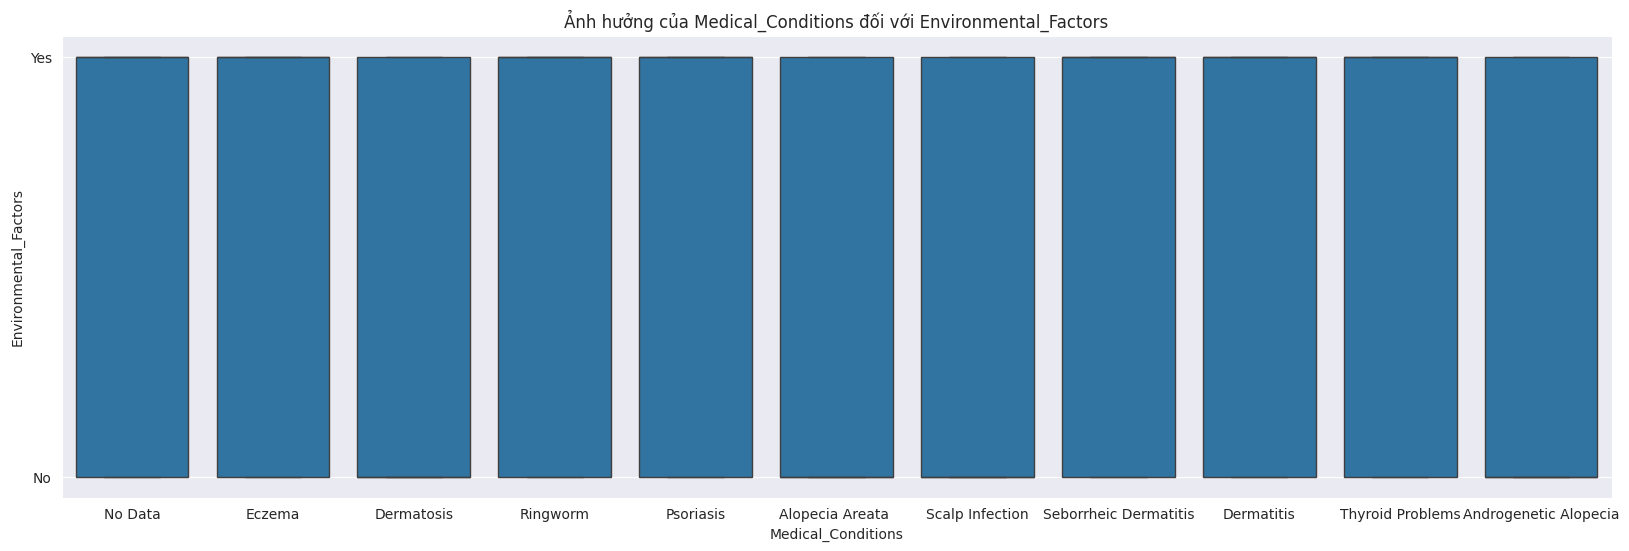

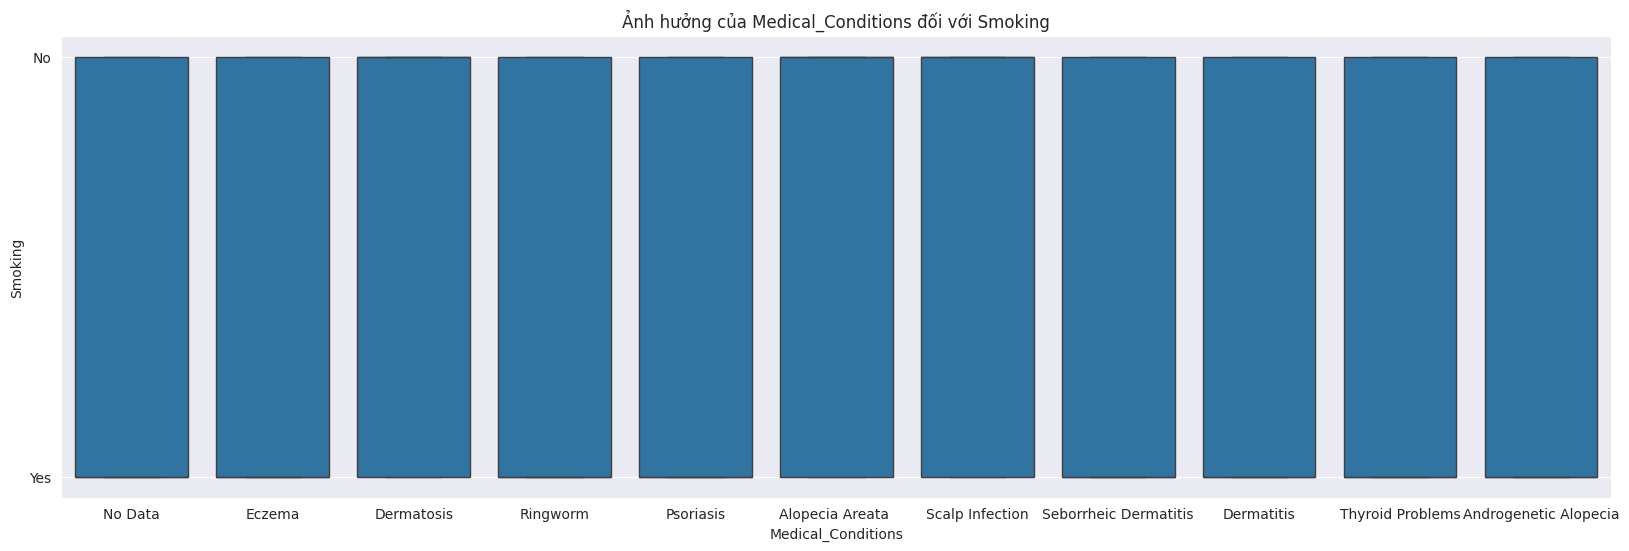

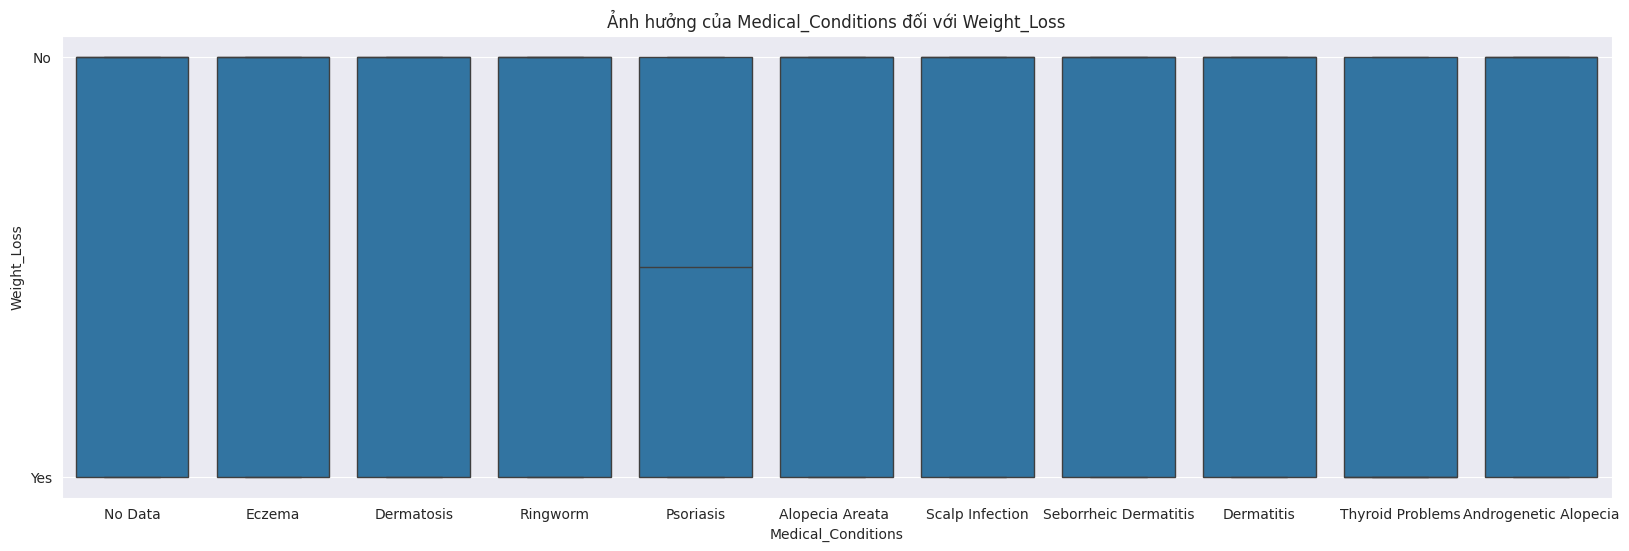

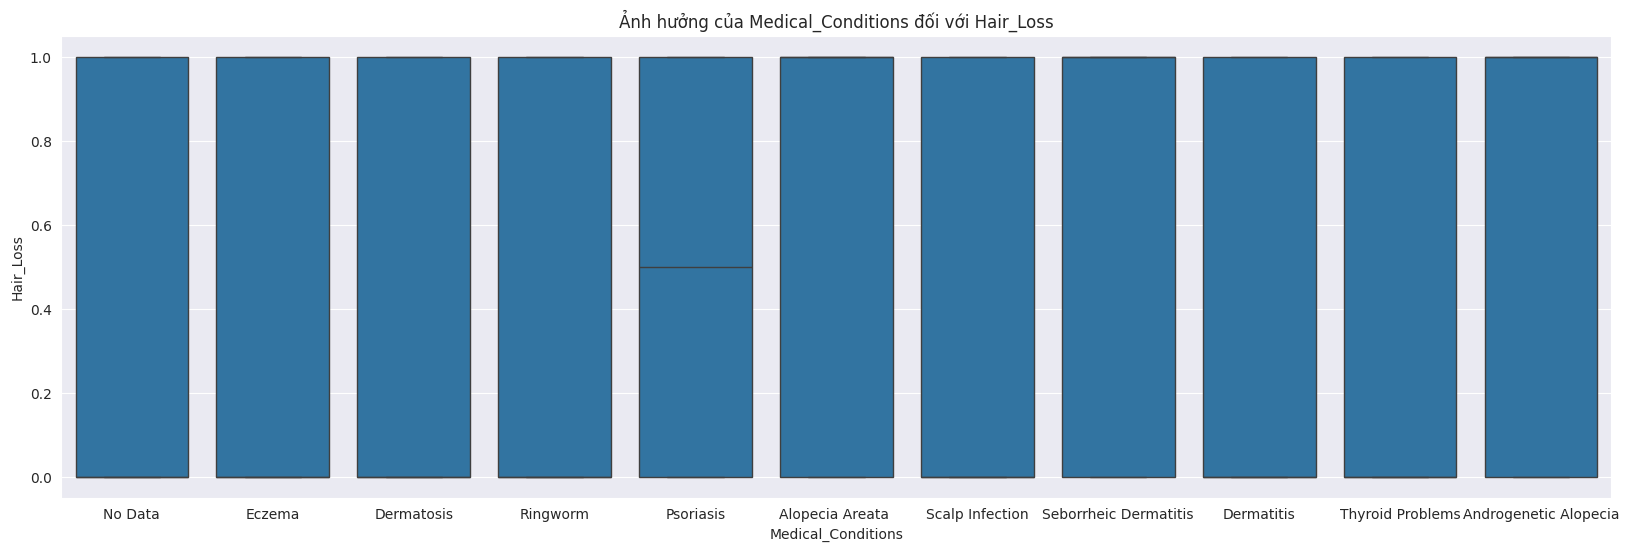

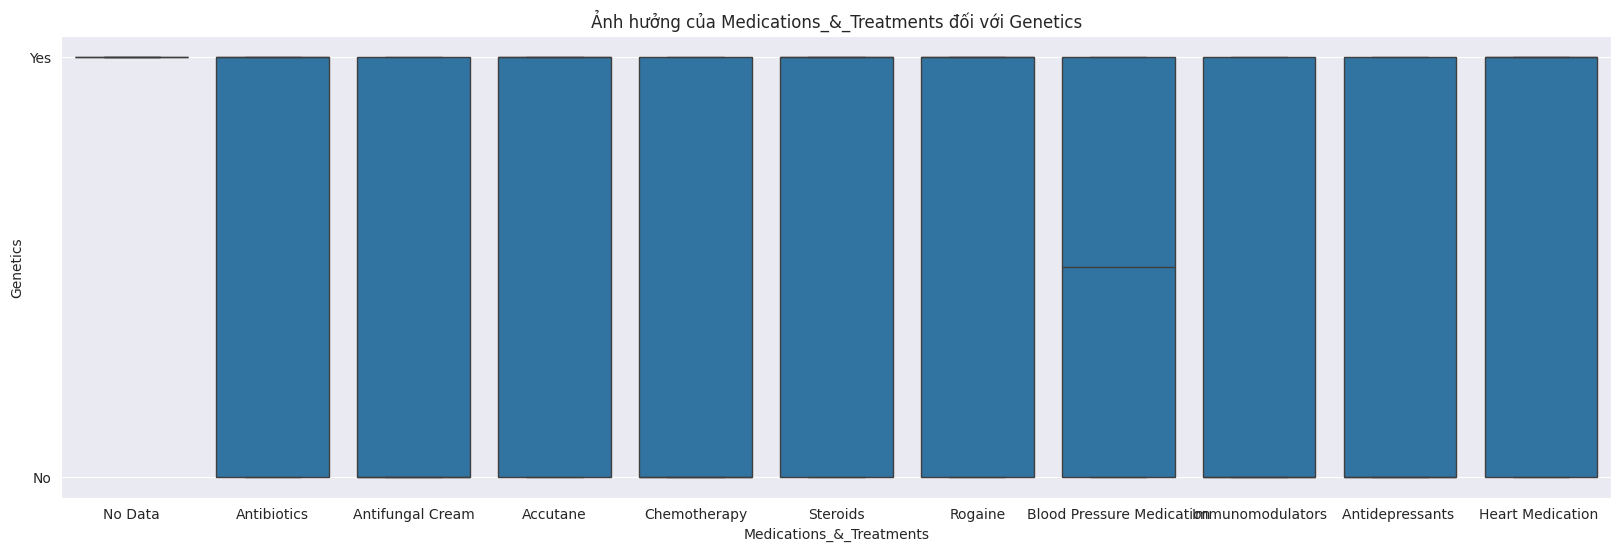

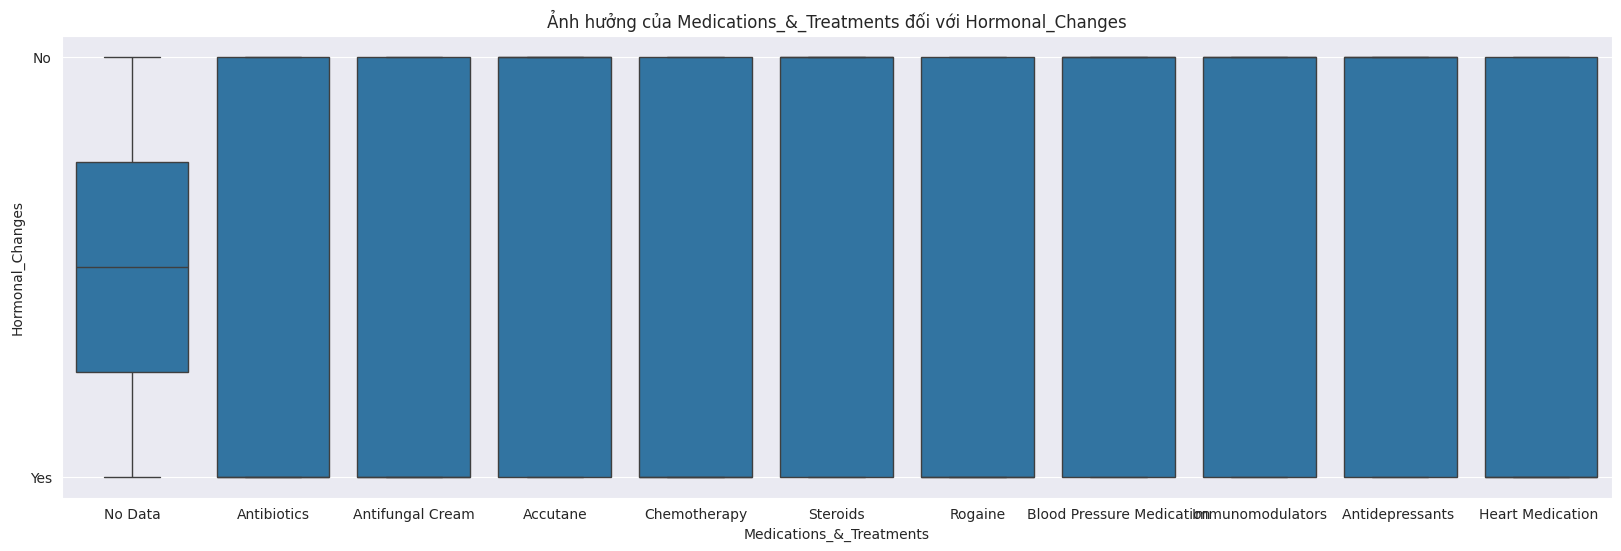

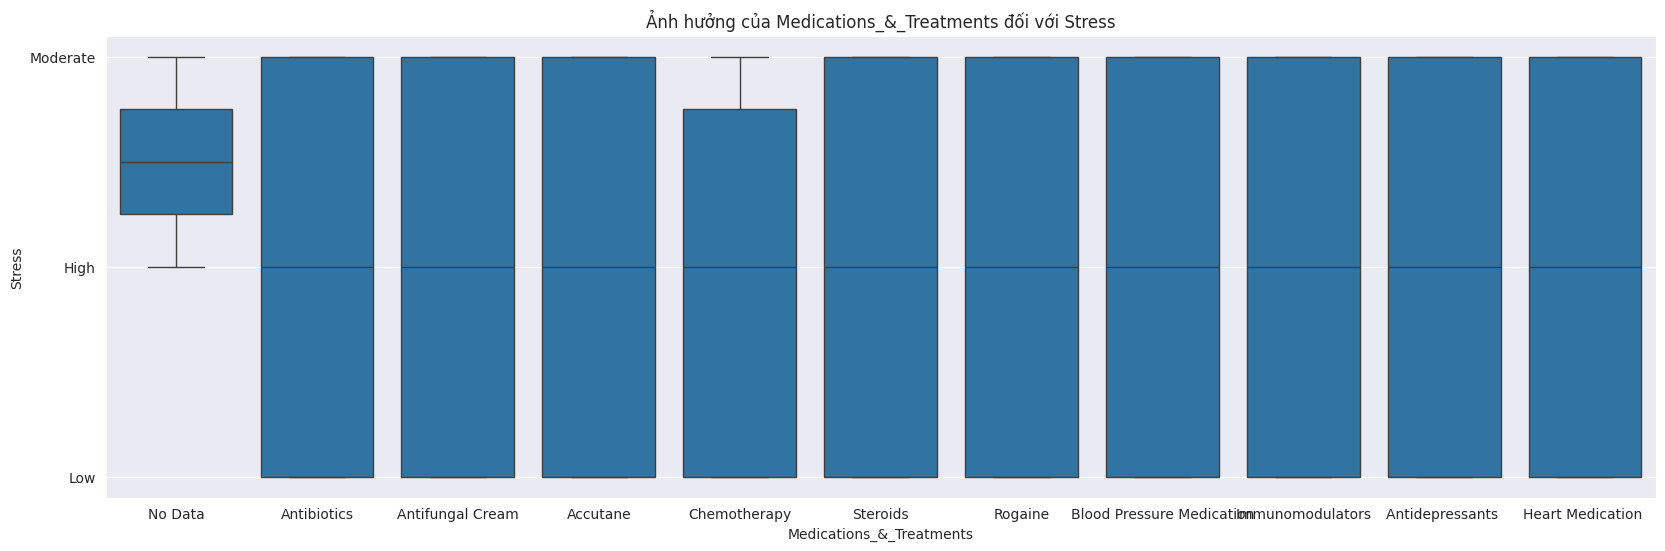

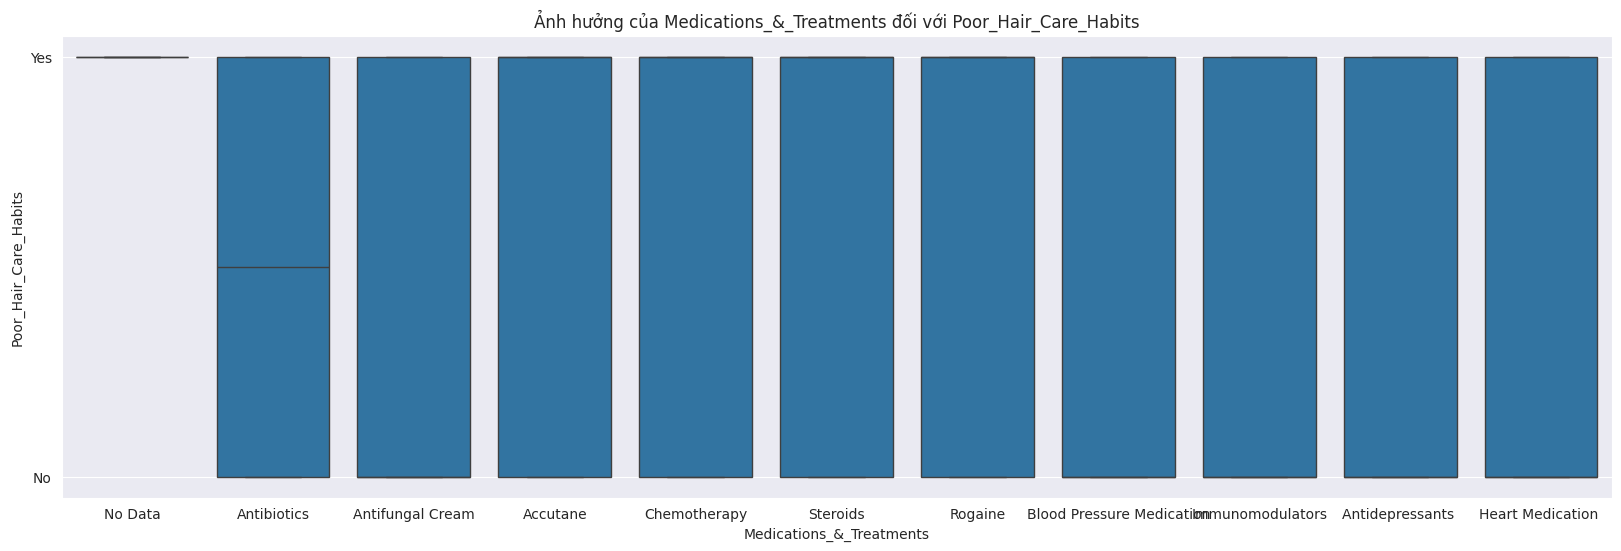

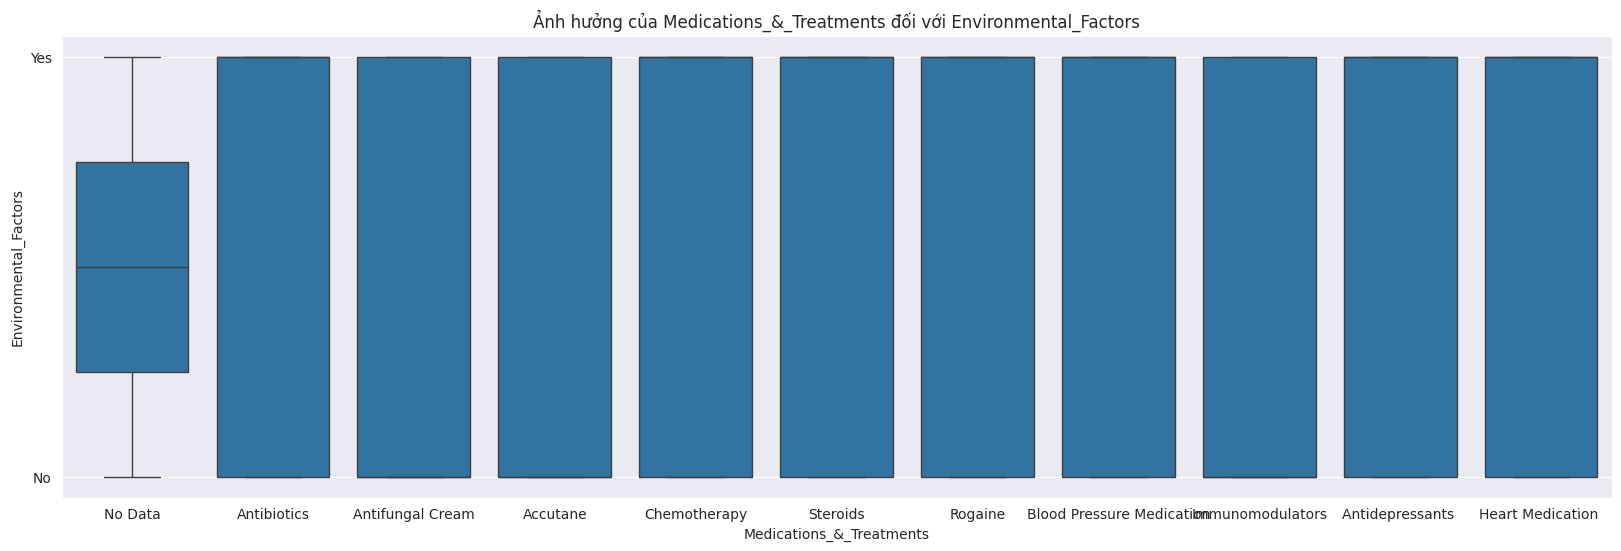

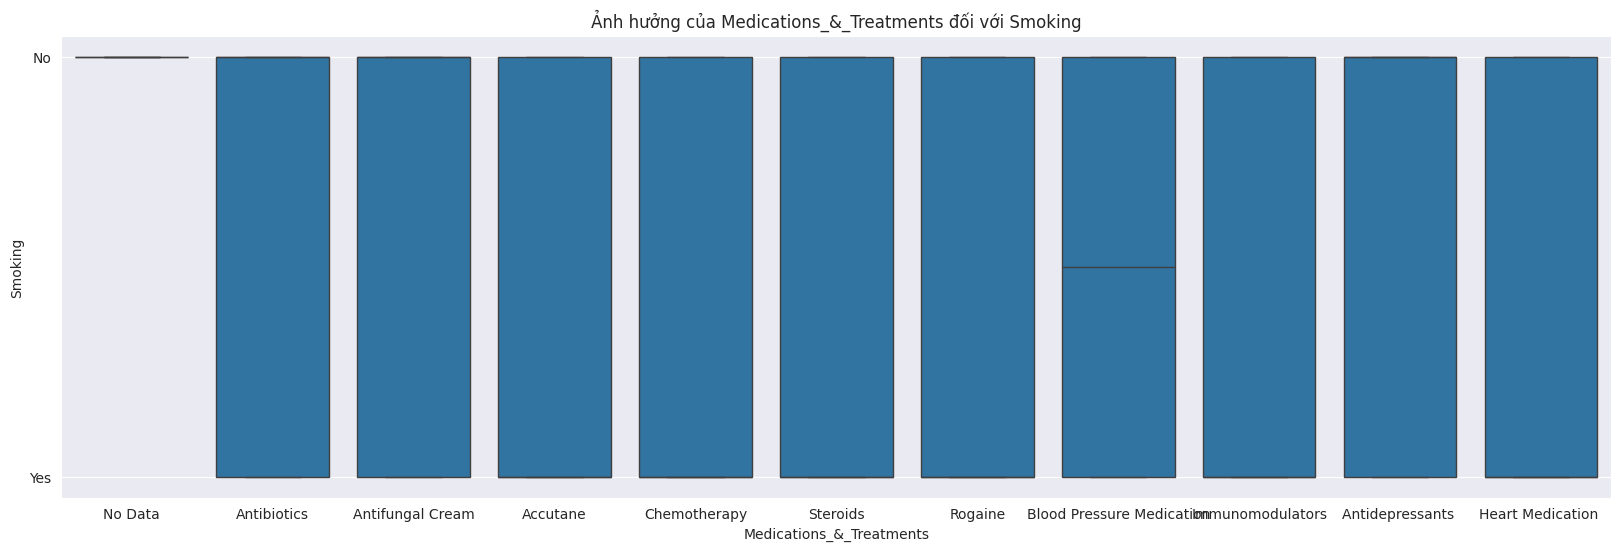

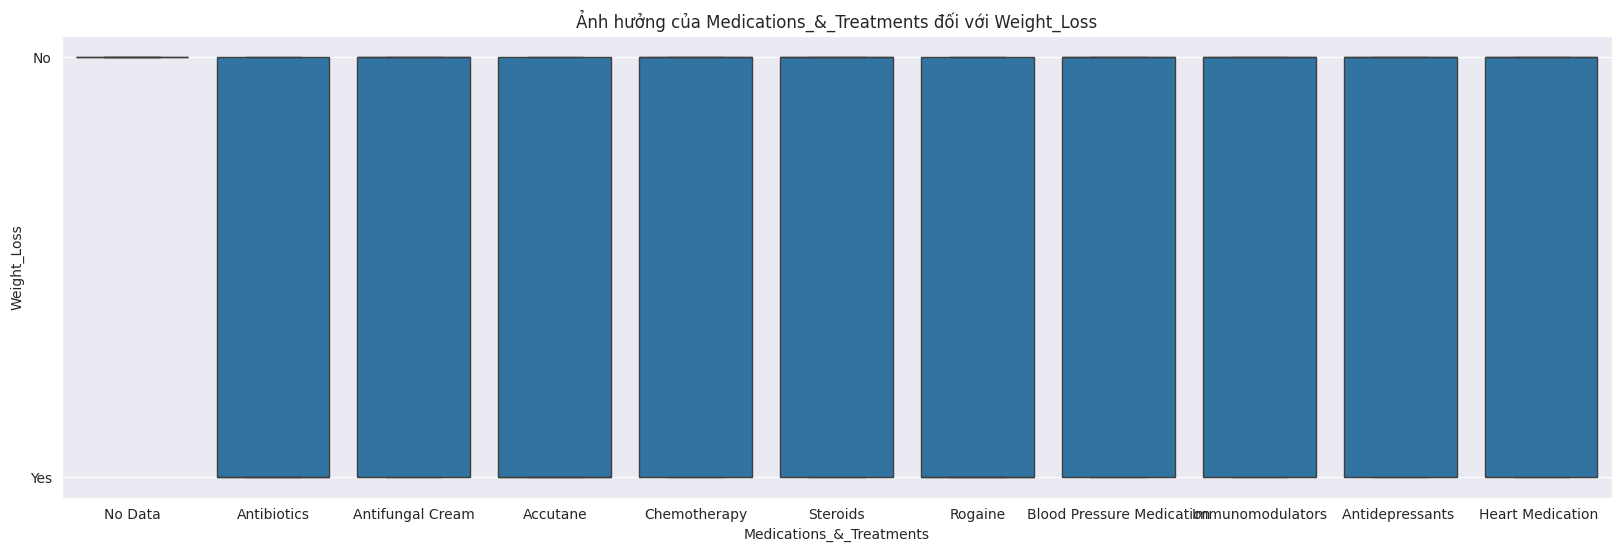

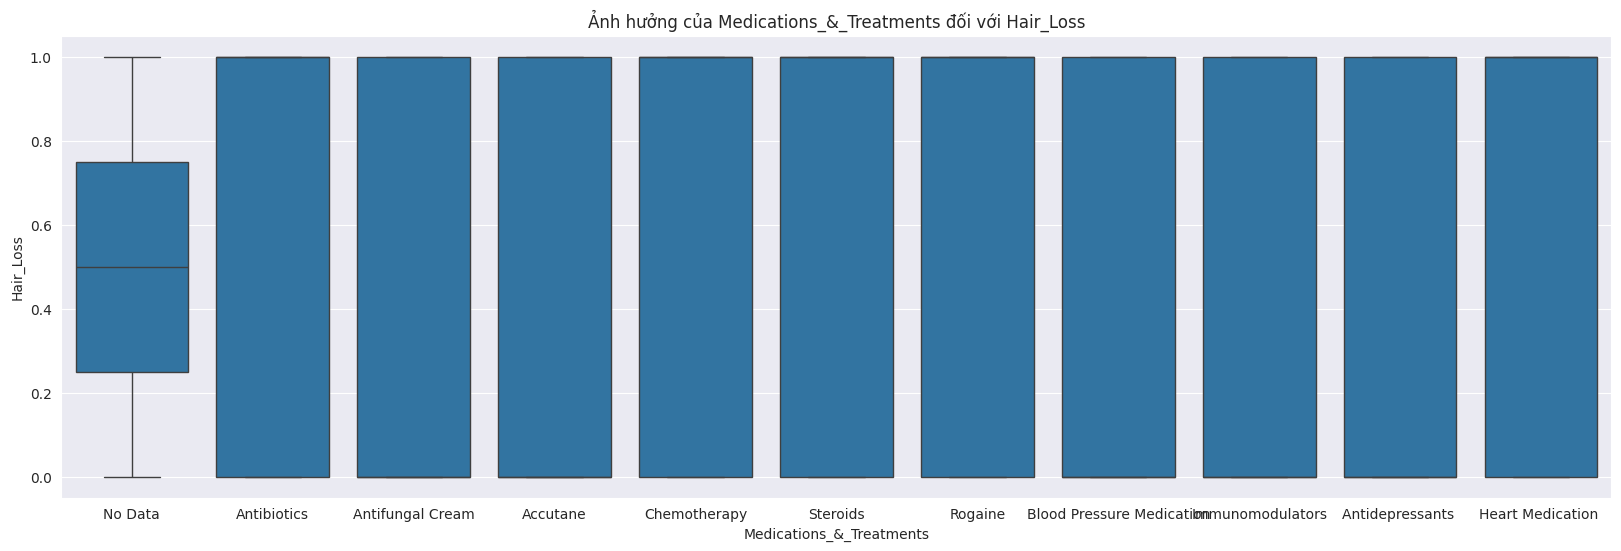

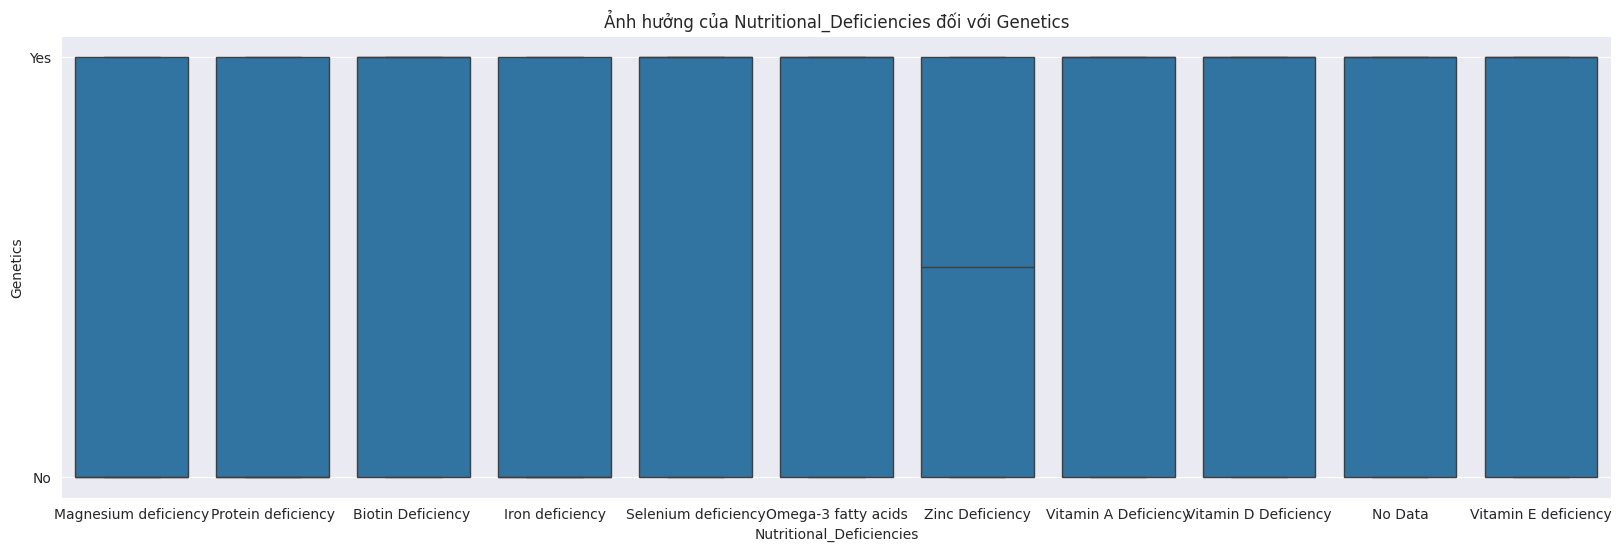

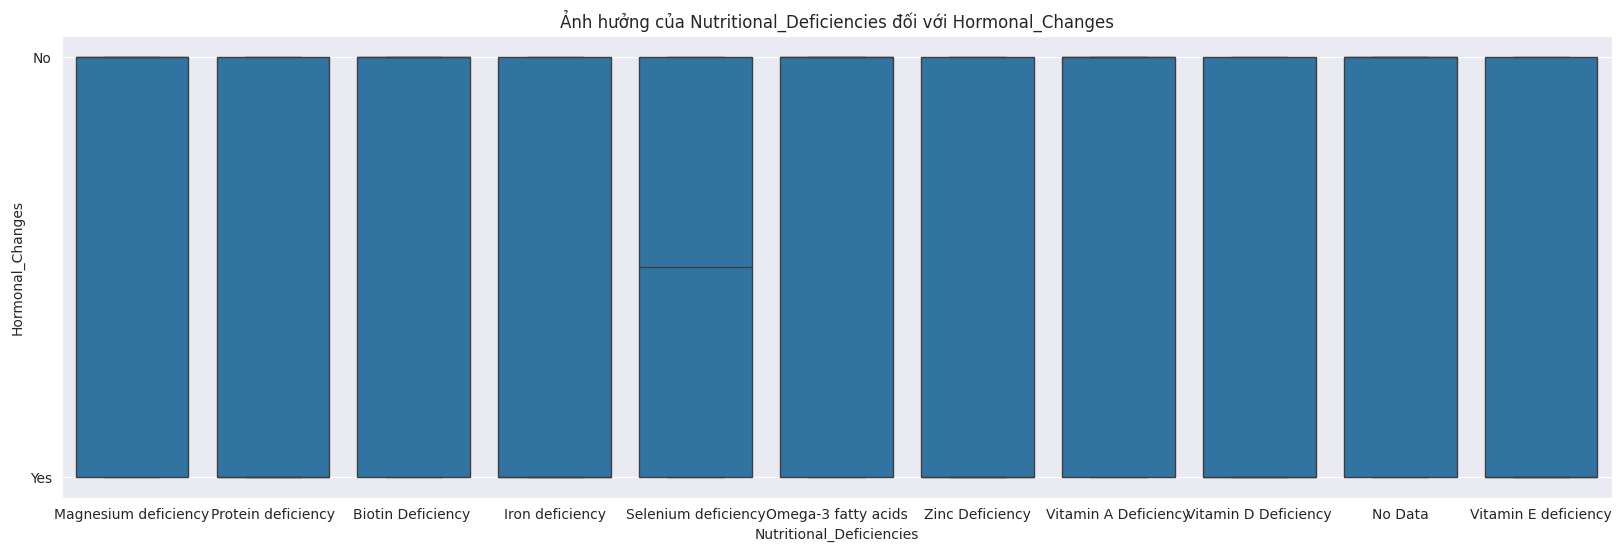

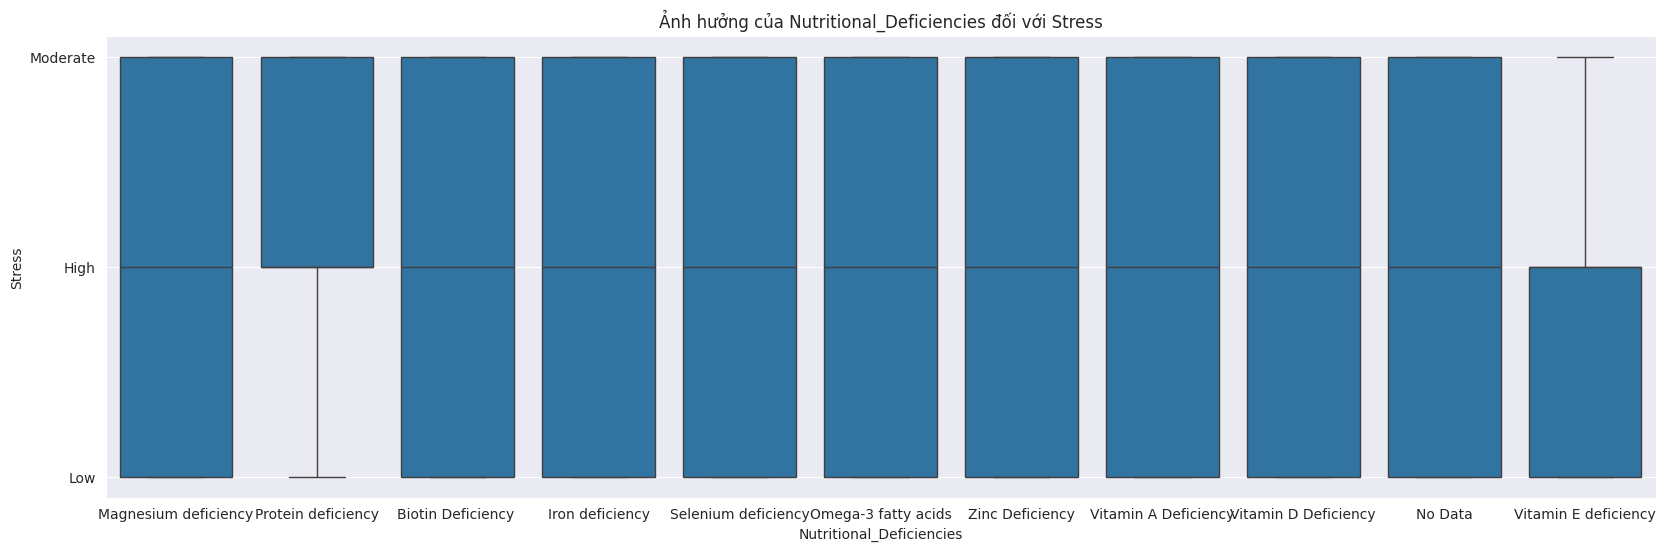

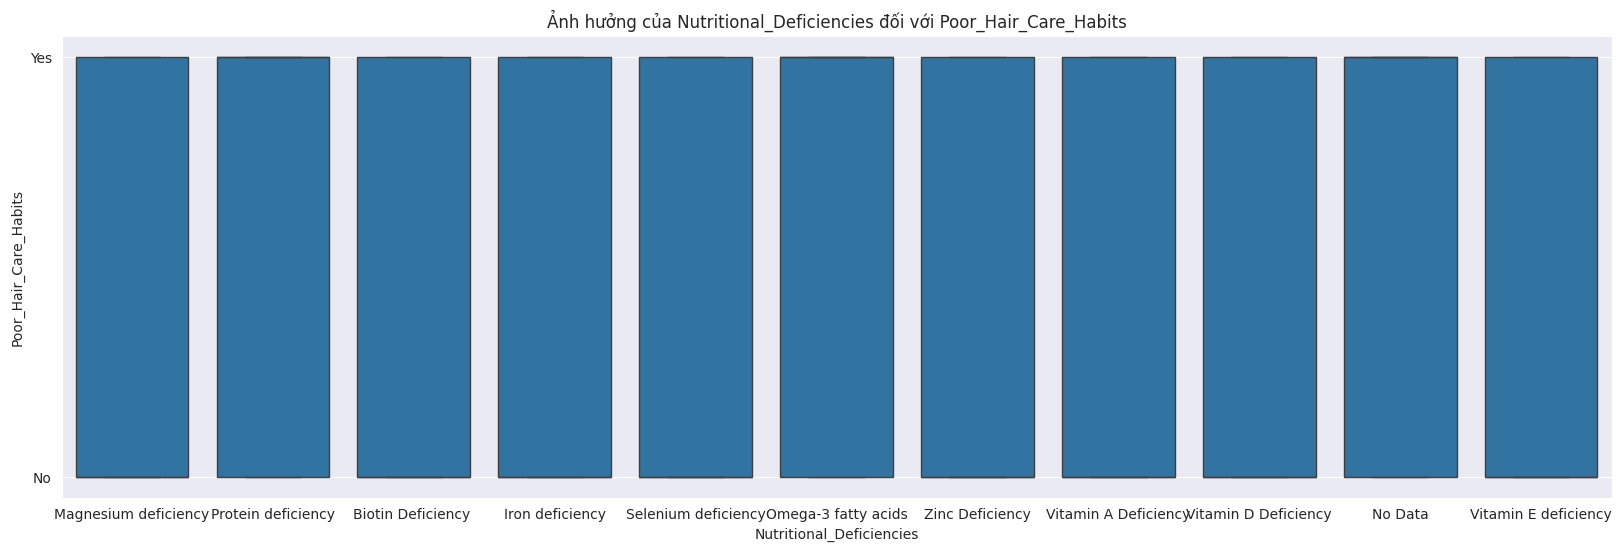

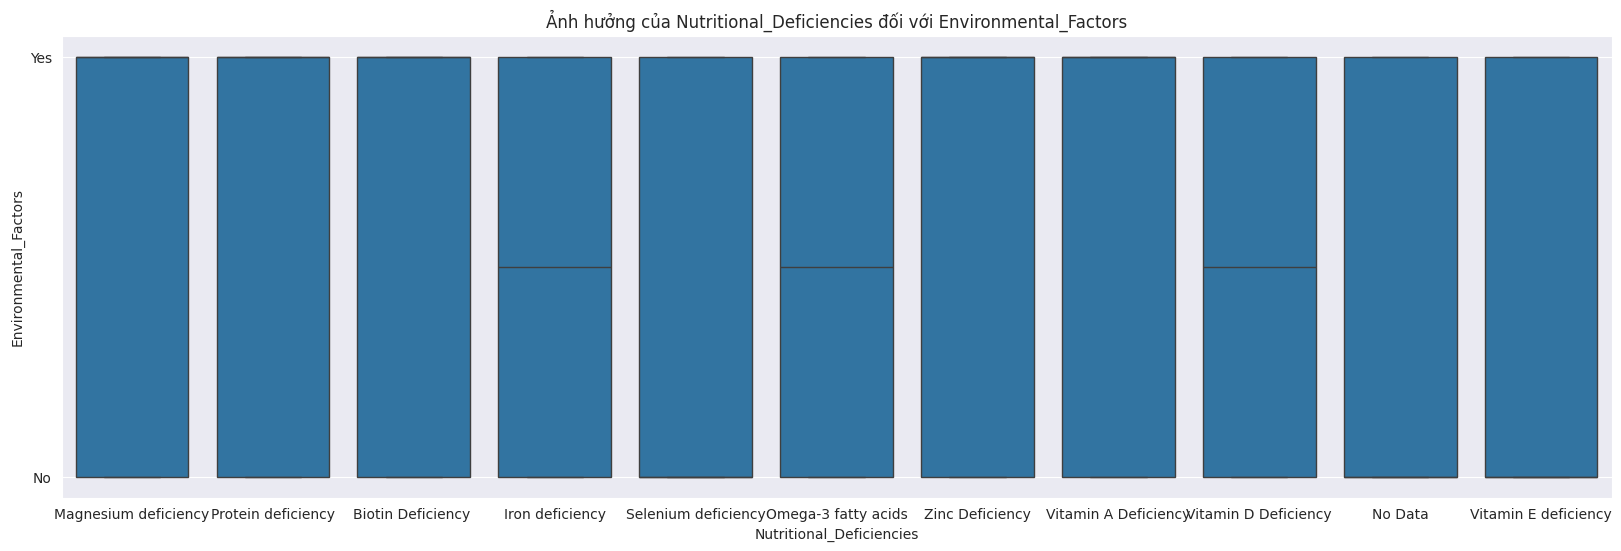

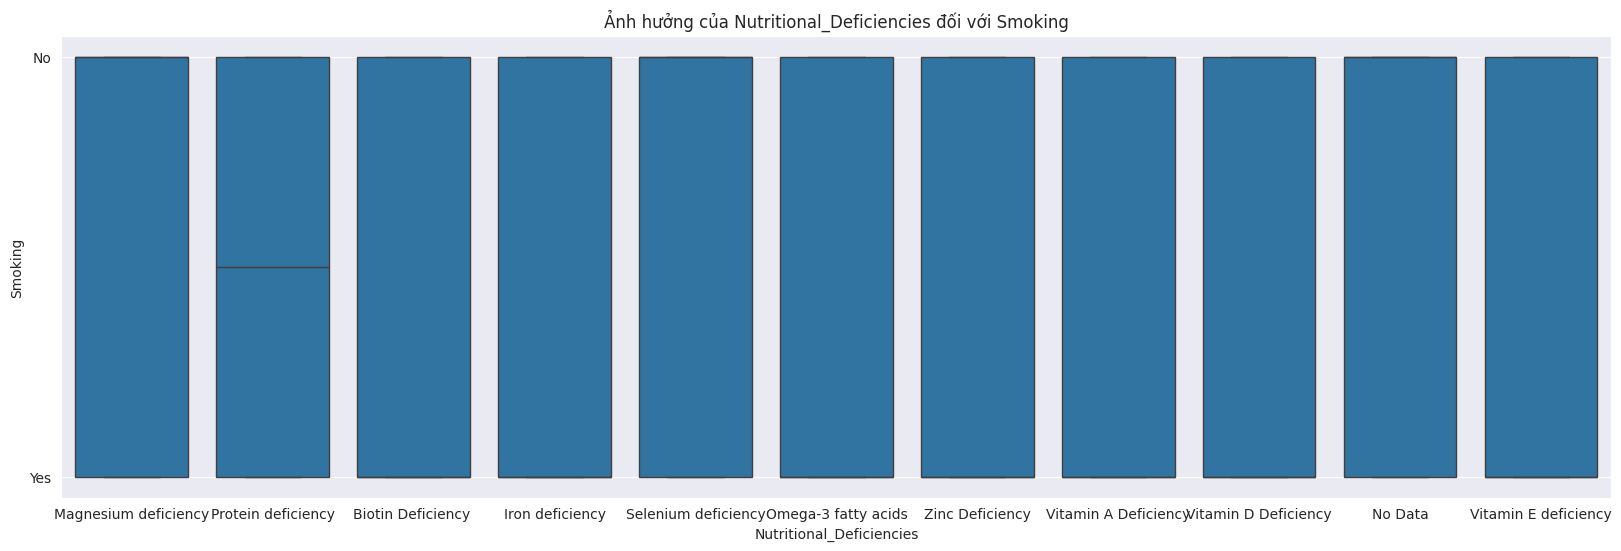

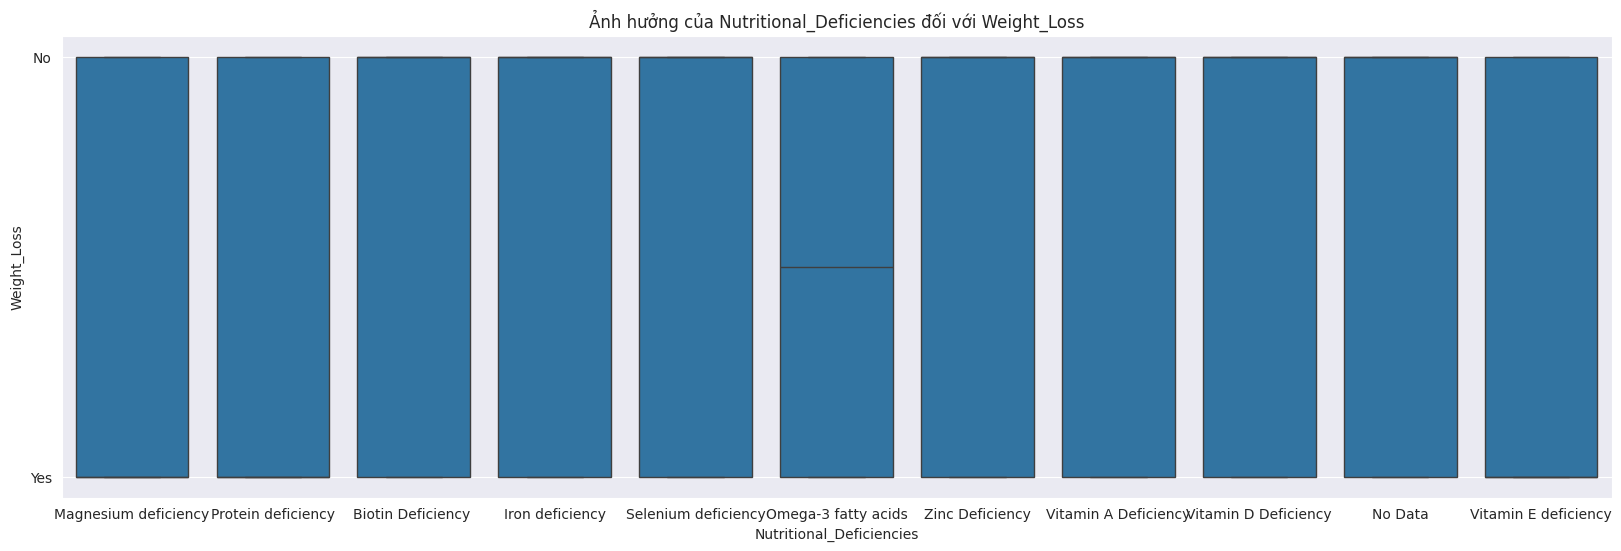

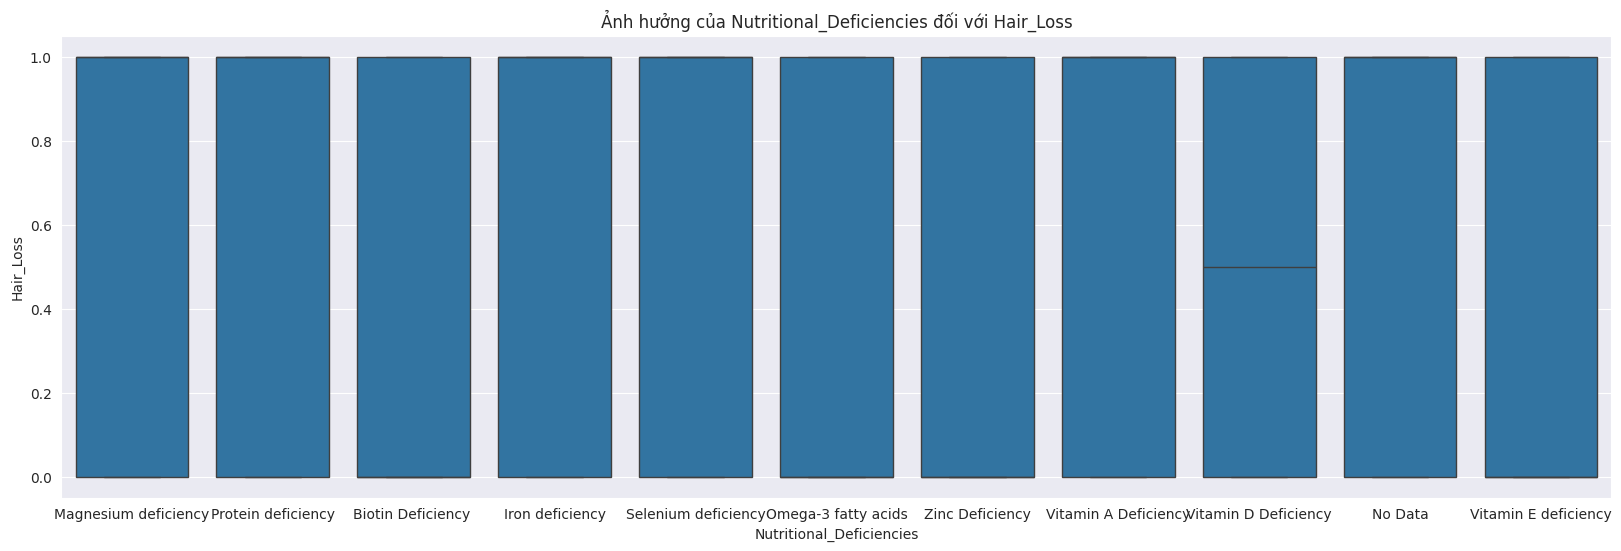

In [ ]:
#Phân tích số và cat
for col in cat_cols:
    for num_col in num_cols:
        plt.figure(figsize=(20, 6))
        sns.boxplot(x=col, y=num_col, data=df)
        plt.title(f"Ảnh hưởng của {col} đối với {num_col}")
        plt.show()